In [1]:
import os 
import glob
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import plotly.express as px
from src.utils import *

# UTIL for aggregating dataset files into one

In [18]:
import os
import json
import glob
import warnings
from collections import defaultdict

def aggregate_ablation_results(datasets, numfeats_list, num_layers=26, input_dir="./ablation_results", output_dir="./aggregated_results", descending=False):
    os.makedirs(output_dir, exist_ok=True)
    descending_str = "True" if descending else "False"
    
    for dataset in datasets:
        # nested dict: dataset[layer][num_feats] -> merged results
        aggregated = defaultdict(lambda: defaultdict(dict))
        missing_data_count = 0

        for layer in [0,5,10,15,20,25]: # range(num_layers)
            for num_feats in numfeats_list:
                # find all batch files for this dataset/layer/num_feats
                pattern = os.path.join(input_dir, f"{dataset}_layer-{layer}_batch-*numfeats-{num_feats}_descending-{descending_str}.json")
                print(f"Processing pattern: {pattern}")
                files = glob.glob(pattern)
                
                # Handle missing files gracefully
                if not files:
                    warning_msg = f"No files found for {dataset}, layer {layer}, num_feats {num_feats}. Skipping this combination."
                    print(f"WARNING: {warning_msg}")
                    warnings.warn(warning_msg, UserWarning)
                    missing_data_count += 1
                    continue
                
                merged = {"operation_ablation": [], "topk_ablation": []}
                files_processed = 0
                
                # concatenate results from all batches
                for file in files:
                    try:
                        with open(file, "r") as f:
                            data = json.load(f)

                        # Handle missing keys in JSON data gracefully
                        if "operation_ablation" in data:
                            merged["operation_ablation"].extend(data["operation_ablation"])
                        else:
                            print(f"WARNING: 'operation_ablation' key missing in {file}")
                            
                        if descending:
                            pass
                        else:
                            if "topk_ablation" in data:
                                merged["topk_ablation"].extend(data["topk_ablation"])
                            else:
                                print(f"WARNING: 'topk_ablation' key missing in {file}")
                        
                        files_processed += 1
                        
                    except (json.JSONDecodeError, IOError) as e:
                        warning_msg = f"Error reading file {file}: {e}. Skipping this file."
                        print(f"WARNING: {warning_msg}")
                        warnings.warn(warning_msg, UserWarning)
                        continue
                
                # Only add to aggregated results if we successfully processed at least one file
                if files_processed > 0:
                    aggregated[layer][num_feats] = merged
                    print(f"Successfully processed {files_processed} files for layer {layer}, num_feats {num_feats}")
                else:
                    warning_msg = f"No valid files could be processed for {dataset}, layer {layer}, num_feats {num_feats}"
                    print(f"WARNING: {warning_msg}")
                    warnings.warn(warning_msg, UserWarning)
                    missing_data_count += 1
        
        # Only save results if we have any data
        if aggregated:
            # save per dataset
            file_name = f"{dataset}_descending.json" if descending else f"{dataset}.json"
            outpath = os.path.join(output_dir, file_name)
            
            try:
                with open(outpath, "w") as f:
                    json.dump(dict(aggregated), f, indent=2)  # Convert defaultdict to regular dict for JSON
                
                print(f"Saved aggregated results for {dataset} -> {outpath}")
                if missing_data_count > 0:
                    print(f"Note: {missing_data_count} combinations had missing or invalid data")
                    
            except IOError as e:
                warning_msg = f"Error saving results for {dataset}: {e}"
                print(f"ERROR: {warning_msg}")
                warnings.warn(warning_msg, UserWarning)
        else:
            warning_msg = f"No valid data found for dataset {dataset}. No output file created."
            print(f"WARNING: {warning_msg}")
            warnings.warn(warning_msg, UserWarning)

# Usage example
datasets = ["random_addition"]  # "random_subtraction"
numfeats = [1, 3, 5, 7, 9, 11]

aggregate_ablation_results(datasets, numfeats, descending=True)

Processing pattern: ./ablation_results/random_addition_layer-0_batch-*numfeats-1_descending-True.json
Successfully processed 625 files for layer 0, num_feats 1
Processing pattern: ./ablation_results/random_addition_layer-0_batch-*numfeats-3_descending-True.json
Successfully processed 625 files for layer 0, num_feats 3
Processing pattern: ./ablation_results/random_addition_layer-0_batch-*numfeats-5_descending-True.json
Successfully processed 625 files for layer 0, num_feats 5
Processing pattern: ./ablation_results/random_addition_layer-0_batch-*numfeats-7_descending-True.json
Successfully processed 625 files for layer 0, num_feats 7
Processing pattern: ./ablation_results/random_addition_layer-0_batch-*numfeats-9_descending-True.json
Successfully processed 625 files for layer 0, num_feats 9
Processing pattern: ./ablation_results/random_addition_layer-0_batch-*numfeats-11_descending-True.json
Successfully processed 625 files for layer 0, num_feats 11
Processing pattern: ./ablation_results

/tmp/ipykernel_1014028/34580877.py:27: UserWarning:

No files found for random_addition, layer 20, num_feats 1. Skipping this combination.



Processing pattern: ./ablation_results/random_addition_layer-20_batch-*numfeats-5_descending-True.json


/tmp/ipykernel_1014028/34580877.py:27: UserWarning:

No files found for random_addition, layer 20, num_feats 3. Skipping this combination.



Processing pattern: ./ablation_results/random_addition_layer-20_batch-*numfeats-7_descending-True.json


...

Processing pattern: ./ablation_results/random_addition_layer-20_batch-*numfeats-11_descending-True.json


/tmp/ipykernel_1014028/34580877.py:27: UserWarning:

No files found for random_addition, layer 20, num_feats 9. Skipping this combination.



Processing pattern: ./ablation_results/random_addition_layer-25_batch-*numfeats-1_descending-True.json


/tmp/ipykernel_1014028/34580877.py:27: UserWarning:

No files found for random_addition, layer 20, num_feats 11. Skipping this combination.



Successfully processed 625 files for layer 25, num_feats 1
Processing pattern: ./ablation_results/random_addition_layer-25_batch-*numfeats-3_descending-True.json
Successfully processed 625 files for layer 25, num_feats 3
Processing pattern: ./ablation_results/random_addition_layer-25_batch-*numfeats-5_descending-True.json
Successfully processed 625 files for layer 25, num_feats 5
Processing pattern: ./ablation_results/random_addition_layer-25_batch-*numfeats-7_descending-True.json
Successfully processed 625 files for layer 25, num_feats 7
Processing pattern: ./ablation_results/random_addition_layer-25_batch-*numfeats-9_descending-True.json
Successfully processed 625 files for layer 25, num_feats 9
Processing pattern: ./ablation_results/random_addition_layer-25_batch-*numfeats-11_descending-True.json
Successfully processed 625 files for layer 25, num_feats 11
Saved aggregated results for random_addition -> ./aggregated_results/random_addition_descending.json
Note: 6 combinations had mis

# Plot top 11 addition and subtration metrics features vs their conttols

In [ ]:
# layers: [0-7], [8-17], [18-25]

# table of mean + std of prompt vs dataset accuracy

In [45]:
# load json file "gemma_scope_math/answers/evaluation_metrics_20250810_194802.json"
import json

# Load the JSON file
with open("./answers/evaluation_metrics_20250810_194802.json", "r") as f:
    data = json.load(f)

# View the top-level type (dict, list, etc.)
print(type(data))

# If it's a dictionary, show the keys
if isinstance(data, dict):
    print("Top-level keys:", data.keys())

# If it's a list, show how many elements and peek at the first one
elif isinstance(data, list):
    print("List length:", len(data))
    if len(data) > 0:
        print("First element keys:", data[0].keys() if isinstance(data[0], dict) else type(data[0]))


import pandas as pd

records = []
for dataset, prompts in data["metrics"].items():
    for prompt, metrics in prompts.items():
        records.append({
            "dataset": dataset,
            "prompt": prompt,
            "accuracy": metrics.get("accuracy", None)
        })

df = pd.DataFrame(records)

# Pivot: rows = prompts, columns = datasets
table = df.pivot(index="prompt", columns="dataset", values="accuracy")

# Row-wise mean ± std
row_stats = table.apply(lambda x: f"{x.mean():.2f} ± {x.std():.2f}", axis=1)
table["mean ± std"] = row_stats

# Column-wise mean ± std
col_stats = table.drop(columns="mean ± std").apply(
    lambda x: f"{x.mean():.2f} ± {x.std():.2f}"
)
table.loc["mean ± std"] = col_stats

print(table)


<class 'dict'>
Top-level keys: dict_keys(['timestamp', 'evaluation_settings', 'datasets_processed', 'prompt_combinations_processed', 'total_combinations', 'metrics'])
dataset             addition random_addition random_subtraction  subtraction  \
prompt                                                                         
answer_directly       0.9625          0.5743             0.5907       0.9072   
answer_suffix         0.0672          0.2119             0.2286       0.2438   
calc_prefix           0.1382          0.3163             0.0545       0.0401   
final_answer          0.4966          0.3311             0.2665       0.4851   
no_prompt             0.1734           0.272             0.2427       0.2632   
space_suffix          0.2952          0.3144              0.161       0.2202   
mean ± std       0.36 ± 0.33     0.34 ± 0.12        0.26 ± 0.18  0.36 ± 0.30   

dataset           mean ± std  
prompt                        
answer_directly  0.76 ± 0.20  
answer_suffix    0.

# Calcualte accuracies and save results

In [2]:
# load addition and random addition.json ./aggregated_results/addition.json
# with open("./aggregated_results/addition.json", "r") as f:
#     addition_data = json.load(f)

with open("./aggregated_results/random_addition.json", "r") as f:
    random_addition_data = json.load(f)

with open("./aggregated_results/addition.json", "r") as f:
    addition_data = json.load(f)

with open("./aggregated_results/random_subtraction.json", "r") as f:
    random_subtraction_data = json.load(f)

with open("./aggregated_results/subtraction.json", "r") as f:
    subtraction_data = json.load(f)

with open("./aggregated_results/random_addition_descending.json", "r") as f:
    random_addition_desc_data = json.load(f)

with open("./aggregated_results/addition_descending.json", "r") as f:
    addition_desc_data = json.load(f)

In [12]:
# Calculate accuracy for each layer and num_feats using functions from utils.py
import pandas as pd
from collections import defaultdict

def calculate_accuracy_matrix(dataset_name, numfeats_list, num_layers=26):
    """
    Calculate accuracy for each layer and num_feats combination
    """
    # Load aggregated data
    with open(f"./aggregated_results/{dataset_name}.json", "r") as f:
        aggregated_data = json.load(f)
    
    # Convert string keys to integers (JSON saves dict keys as strings)
    data = defaultdict(lambda: defaultdict(dict))
    for layer_str, layer_data in aggregated_data.items():
        layer = int(layer_str)
        for num_feats_str, feats_data in layer_data.items():
            num_feats = int(num_feats_str)
            data[layer][num_feats] = feats_data
    
    # Load the original dataset to generate correct answers
    dataset_path = f"./data/{dataset_name}.txt"
    
    results = defaultdict(lambda: defaultdict(lambda: defaultdict(dict)))
    
    for layer in range(num_layers):
        for num_feats in numfeats_list:
            if layer in data and num_feats in data[layer]:
                print(f"Processing {dataset_name} - Layer {layer}, Num feats {num_feats}")
                
                # Get the ablation results for this configuration
                layer_data = data[layer][num_feats]
                
                # Generate correct answers for this subset
                # First, extract prompts to determine how many samples we have
                if "operation_ablation" in layer_data and layer_data["operation_ablation"]:
                    sample_prompts = [item[0] for item in layer_data["operation_ablation"]]
                    
                    # Generate correct answers for these specific prompts
                    correct_answers = []
                    for prompt in sample_prompts:
                        # Extract the math problem from the prompt (remove "Answer directly: " prefix)
                        problem = prompt.replace("Answer directly: ", "").replace("= ", "").strip()
                        correct_answer = calc_correct_answer(problem)
                        correct_answers.append((prompt, correct_answer))
                    
                    # Calculate accuracy for each condition
                    for condition in ["operation_ablation", "topk_ablation"]:
                        if condition in layer_data and layer_data[condition]:
                            model_results = [(item[0], item[1]) for item in layer_data[condition]]
                            
                            # Calculate accuracy
                            accuracy, correct_count, total_count, detailed_results, skipped_count = calculate_accuracy(
                                model_results, correct_answers
                            )
                            
                            # Store all metrics in a dictionary
                            results[condition][layer][num_feats] = {
                                'accuracy': accuracy,
                                'correct_count': correct_count,
                                'total_count': total_count,
                                'skipped_count': skipped_count
                            }
                            
                            print(f"  {condition}: {accuracy:.3f} ({correct_count}/{total_count}, skipped: {skipped_count})")
                else:
                    print(f"  No data found for Layer {layer}, Num feats {num_feats}")
    
    return results

# Calculate accuracy matrices for each dataset
datasets = [ "random_addition", "addition", "subtraction", "random_subtraction", "random_addition_descending", "addition_descending"]
numfeats = [0, 1, 3, 5, 7, 9, 11]

accuracy_results = {}
for dataset in datasets:
    print(f"\n{'='*50}")
    print(f"Processing {dataset.upper()}")
    print(f"{'='*50}")
    try:
        accuracy_results[dataset] = calculate_accuracy_matrix(dataset, numfeats)
    except FileNotFoundError as e:
        print(f"Error processing {dataset}: {e}")
        continue

print("\nAccuracy calculation completed!")


Processing RANDOM_ADDITION
Processing random_addition - Layer 0, Num feats 1
  operation_ablation: 0.709 (7086/10000, skipped: 2014)
Processing random_addition - Layer 0, Num feats 1
  operation_ablation: 0.709 (7086/10000, skipped: 2014)
  topk_ablation: 0.709 (7086/10000, skipped: 2014)
Processing random_addition - Layer 0, Num feats 3
  operation_ablation: 0.700 (7001/10000, skipped: 2095)
  topk_ablation: 0.709 (7086/10000, skipped: 2014)
Processing random_addition - Layer 0, Num feats 5
  topk_ablation: 0.709 (7086/10000, skipped: 2014)
Processing random_addition - Layer 0, Num feats 3
  operation_ablation: 0.700 (7001/10000, skipped: 2095)
  topk_ablation: 0.709 (7086/10000, skipped: 2014)
Processing random_addition - Layer 0, Num feats 5
  operation_ablation: 0.700 (7001/10000, skipped: 2095)
  topk_ablation: 0.709 (7089/10000, skipped: 2008)
Processing random_addition - Layer 0, Num feats 7
  operation_ablation: 0.700 (7001/10000, skipped: 2095)
  topk_ablation: 0.709 (7089/10

In [13]:
# open a json file and explore keys
with open("answers/baseline_metrics.json", "r") as f:
    baselines = json.load(f)

for dataset in datasets:
    for layer in range(26):
        for condition in ["operation_ablation", "topk_ablation"]:
            if "desc" in dataset:
                if condition == "topk_ablation":
                    continue
                # For descending datasets, only accuracy is available
                metric_value = baselines['metrics'][dataset.removesuffix("_descending")]['answer_directly']['accuracy']
                accuracy_results[dataset][condition][layer][0] = {
                    'accuracy': metric_value,
                    'correct_count': None,  # Not available for descending datasets
                    'total_count': None,    # Not available for descending datasets  
                    'skipped_count': None   # Not available for descending datasets
                }
            else:
                # For non-descending datasets, extract all available metrics
                baseline_metrics = baselines['metrics'][dataset]['answer_directly']
                accuracy_results[dataset][condition][layer][0] = {
                    'accuracy': baseline_metrics['accuracy'],
                    'correct_count': baseline_metrics['correct_count'],
                    'total_count': baseline_metrics['total_count'],
                    'skipped_count': baseline_metrics['skipped_count']
                }

In [15]:
# Check the structure of accuracy_results and save to json
print("Sample structure of accuracy_results:")
if accuracy_results:
    # Show a sample entry to demonstrate the new structure
    sample_dataset = list(accuracy_results.keys())[0]
    sample_condition = list(accuracy_results[sample_dataset].keys())[0] 
    sample_layer = list(accuracy_results[sample_dataset][sample_condition].keys())[0]
    sample_numfeats = list(accuracy_results[sample_dataset][sample_condition][sample_layer].keys())[0]
    
    sample_value = accuracy_results[sample_dataset][sample_condition][sample_layer][sample_numfeats]
    print(f"Sample entry for {sample_dataset}[{sample_condition}][{sample_layer}][{sample_numfeats}]:")
    print(f"Type: {type(sample_value)}")
    print(f"Value: {sample_value}")

# save the accuracy_results to json
with open("./aggregated_results/accuracy_results_with_counts.json", "w") as f:
    json.dump(accuracy_results, f, indent=2)

print(f"\nSaved accuracy results with counts to: ./aggregated_results/accuracy_results_with_counts.json")

Sample structure of accuracy_results:
Sample entry for random_addition[operation_ablation][0][1]:
Type: <class 'dict'>
Value: {'accuracy': 0.7086, 'correct_count': 7086, 'total_count': 10000, 'skipped_count': 2014}

Saved accuracy results with counts to: ./aggregated_results/accuracy_results_with_counts.json


# Plot accuracies for ablation vs control

In [ ]:
# TODO: LOAD RESULTS FROM ./aggregated_results/accuracy_results_with_counts.json
# TODO: MODIFY PLOTTING CODE TO PULL ACCURACY FROM THE "accuracy" KEY IN THE DICTIONARY

In [ ]:
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Default feature numbers
FEATURE_NUMS = [0, 1, 3, 5, 7, 9, 11]

def extract_accuracy(metric_dict):
    """Helper function to extract accuracy from metric dictionary or return as-is if it's already a float"""
    if isinstance(metric_dict, dict):
        return metric_dict.get('accuracy', 0)
    return metric_dict

def plot_accuracy_by_features_per_layer(accuracy_results, plot_configs, 
                                        feature_nums=FEATURE_NUMS, 
                                        max_layers=26, layers=None):
    """
    Matplotlib: Create one plot per layer showing accuracy vs number of ablated features.
    You can pass a list of specific layers via `layers`.
    """
    if layers is None:
        layers = list(range(max_layers))

    fig, axes = plt.subplots(6, 5, figsize=(20, 24))
    axes = axes.flatten()

    for idx, layer in enumerate(layers[:len(axes)]):
        ax = axes[idx]

        for (dataset, condition), config in plot_configs.items():
            if dataset in accuracy_results and condition in accuracy_results[dataset] and layer in accuracy_results[dataset][condition]:
                accuracies, valid_features = [], []
                for num_feats in feature_nums:
                    if num_feats in accuracy_results[dataset][condition][layer]:
                        accuracy = extract_accuracy(accuracy_results[dataset][condition][layer][num_feats])
                        accuracies.append(accuracy)
                        valid_features.append(num_feats)
                if accuracies:
                    ax.plot(valid_features, accuracies,
                            color=config['color'],
                            linestyle=config['linestyle'],
                            marker=config['marker'],
                            label=config['label'],
                            linewidth=2,
                            markersize=6)

        ax.set_title(f'Layer {layer}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Number of Ablated Features')
        ax.set_ylabel('Accuracy')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 1)
        ax.set_xticks(feature_nums)
        if idx == 0:
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    for i in range(len(layers), len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.suptitle('Accuracy vs Number of Ablated Features by Layer', fontsize=16, fontweight='bold', y=0.98)
    plt.show()


def plot_accuracy_by_features_interactive(accuracy_results, plot_configs,
                                          feature_nums=FEATURE_NUMS, 
                                          max_layers=26, layers=None):
    """
    Plotly: Create interactive plots showing accuracy vs number of ablated features.
    You can pass a list of specific layers via `layers`.
    """
    if layers is None:
        layers = list(range(max_layers))

    rows, cols = 6, 5
    subplot_titles = [f'Layer {l}' for l in layers]
    fig = make_subplots(rows=rows, cols=cols,
                        subplot_titles=subplot_titles[:rows*cols],
                        vertical_spacing=0.08, horizontal_spacing=0.06)

    for idx, layer in enumerate(layers[:rows*cols]):
        row, col = idx // cols + 1, idx % cols + 1
        for (dataset, condition), config in plot_configs.items():
            if dataset in accuracy_results and condition in accuracy_results[dataset] and layer in accuracy_results[dataset][condition]:
                accuracies, valid_features = [], []
                for num_feats in feature_nums:
                    if num_feats in accuracy_results[dataset][condition][layer]:
                        accuracy = extract_accuracy(accuracy_results[dataset][condition][layer][num_feats])
                        accuracies.append(accuracy)
                        valid_features.append(num_feats)
                if accuracies:
                    fig.add_trace(
                        go.Scatter(
                            x=valid_features,
                            y=accuracies,
                            mode='lines+markers',
                            name=config['name'],
                            line=dict(color=config['color'], dash=config['dash'], width=2),
                            marker=dict(symbol=config['symbol'], size=6),
                            showlegend=(idx == 0),
                            legendgroup=config['name']
                        ),
                        row=row, col=col
                    )
        fig.update_xaxes(title_text="Features" if row == rows else "", tickvals=feature_nums, row=row, col=col)
        fig.update_yaxes(title_text="Accuracy" if col == 1 else "", range=[0, 1], row=row, col=col)

    fig.update_layout(title_text="Accuracy vs Number of Ablated Features by Layer",
                      height=1200, showlegend=True,
                      legend=dict(x=1.02, y=1, xanchor="left", yanchor="top"))
    fig.show()


def plot_individual_layer_plots(accuracy_results, plot_configs, 
                                feature_nums=FEATURE_NUMS, 
                                max_layers=26, layers=None, figsize=(10, 6)):
    """
    Matplotlib: Create one full-size plot per layer.
    You can pass a list of specific layers via `layers`.
    """
    if layers is None:
        layers = list(range(max_layers))

    for layer in layers:
        plt.figure(figsize=figsize)
        for (dataset, condition), config in plot_configs.items():
            if dataset in accuracy_results and condition in accuracy_results[dataset] and layer in accuracy_results[dataset][condition]:
                accuracies, valid_features = [], []
                for num_feats in feature_nums:
                    if num_feats in accuracy_results[dataset][condition][layer]:
                        accuracy = extract_accuracy(accuracy_results[dataset][condition][layer][num_feats])
                        accuracies.append(accuracy)
                        valid_features.append(num_feats)
                if accuracies:
                    plt.plot(valid_features, accuracies,
                             color=config['color'],
                             linestyle=config['linestyle'],
                             marker=config['marker'],
                             label=config['label'],
                             linewidth=config['linewidth'],
                             markersize=config['markersize'],
                             markeredgewidth=1,
                             markeredgecolor='white')

        plt.title(f'Layer {layer} - Accuracy vs Number of Ablated Features', fontsize=16, fontweight='bold', pad=20)
        plt.xlabel('Number of Ablated Features', fontsize=14)
        plt.ylabel('Accuracy', fontsize=14)
        plt.grid(True, alpha=0.3, linestyle=':', linewidth=1)
        plt.ylim(0, 1.05)
        plt.xlim(-0.5, 11.5)
        plt.xticks(feature_nums, fontsize=12)
        plt.yticks(fontsize=12)
        plt.legend(loc='best', fontsize=11, frameon=True, fancybox=True, shadow=True, framealpha=0.9)
        plt.tight_layout()
        plt.show()
        print(f"\n{'='*60}")


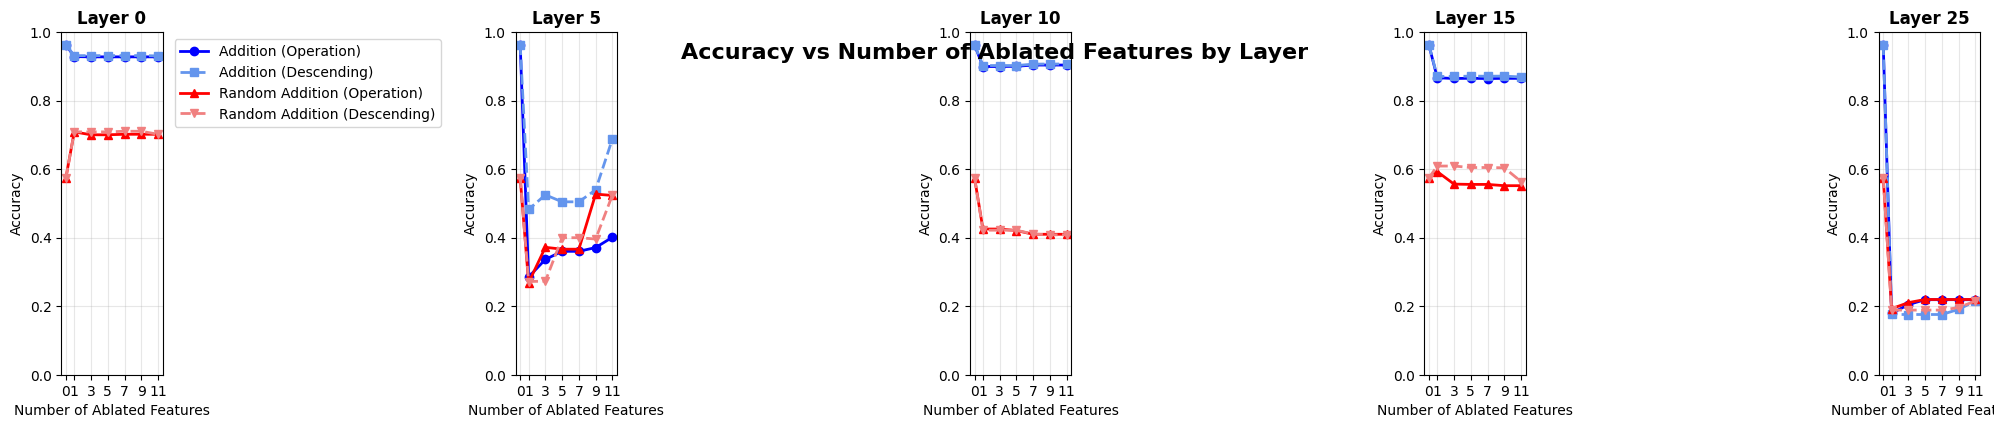

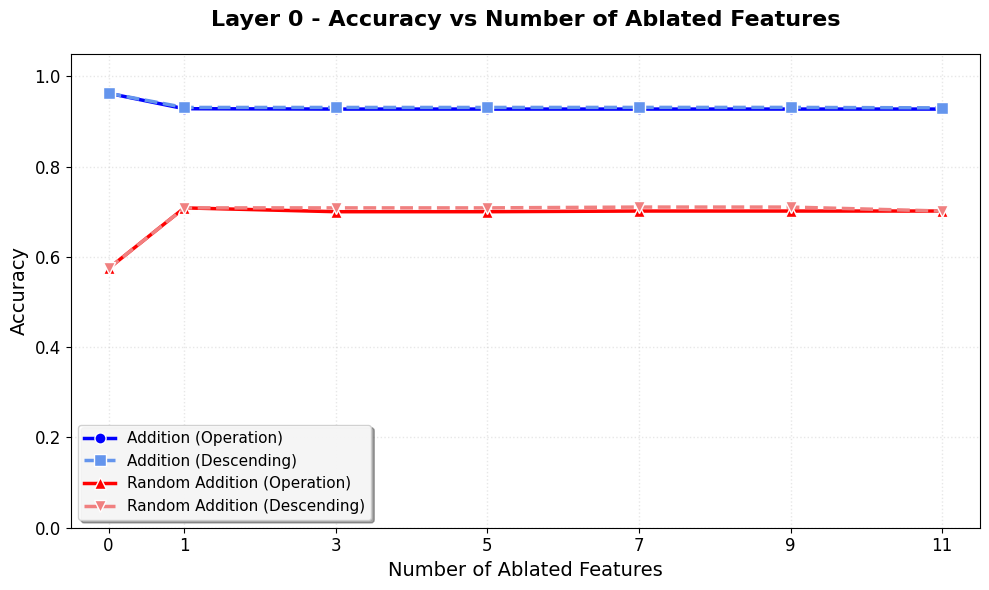

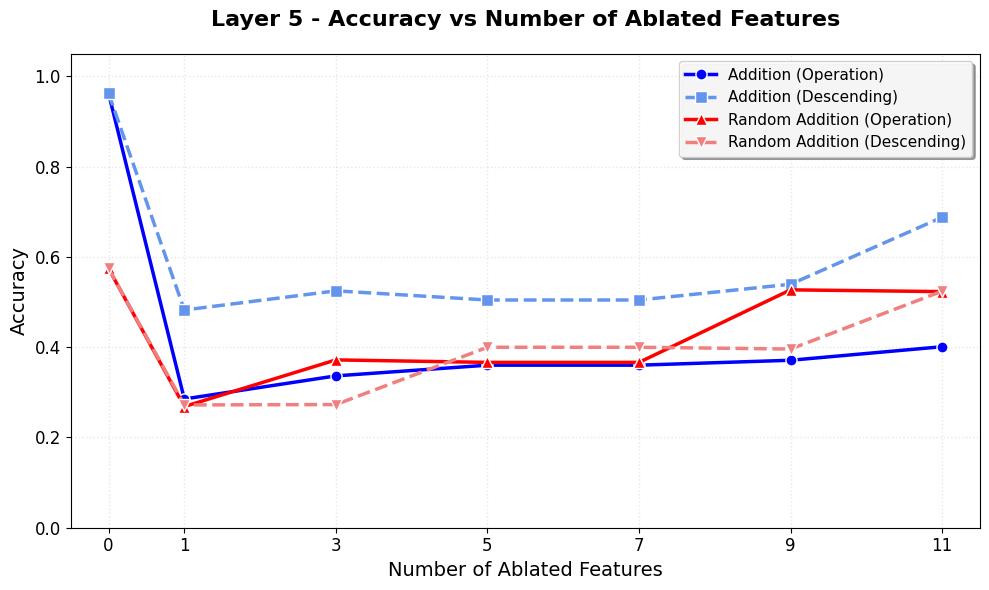

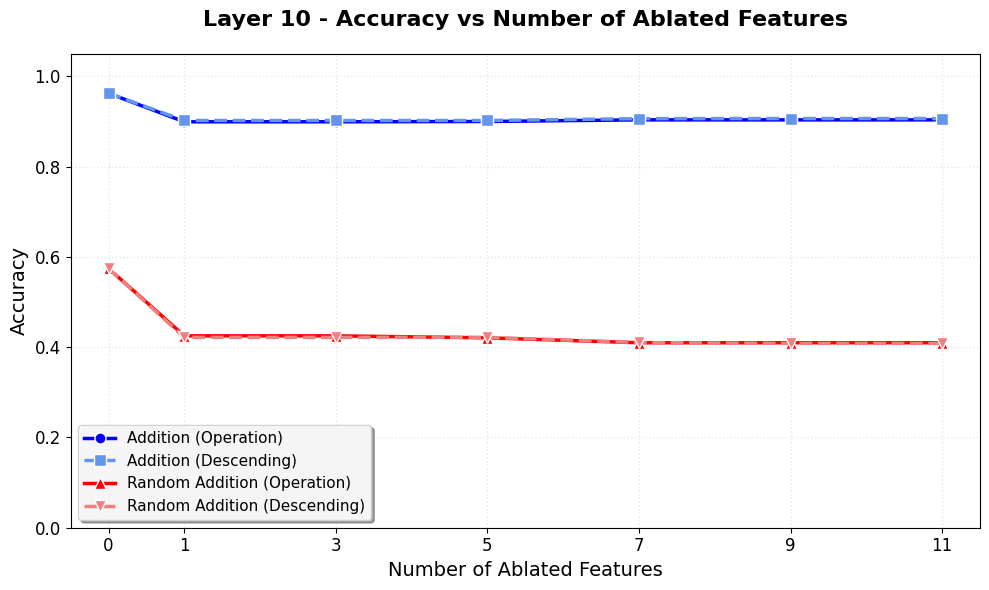

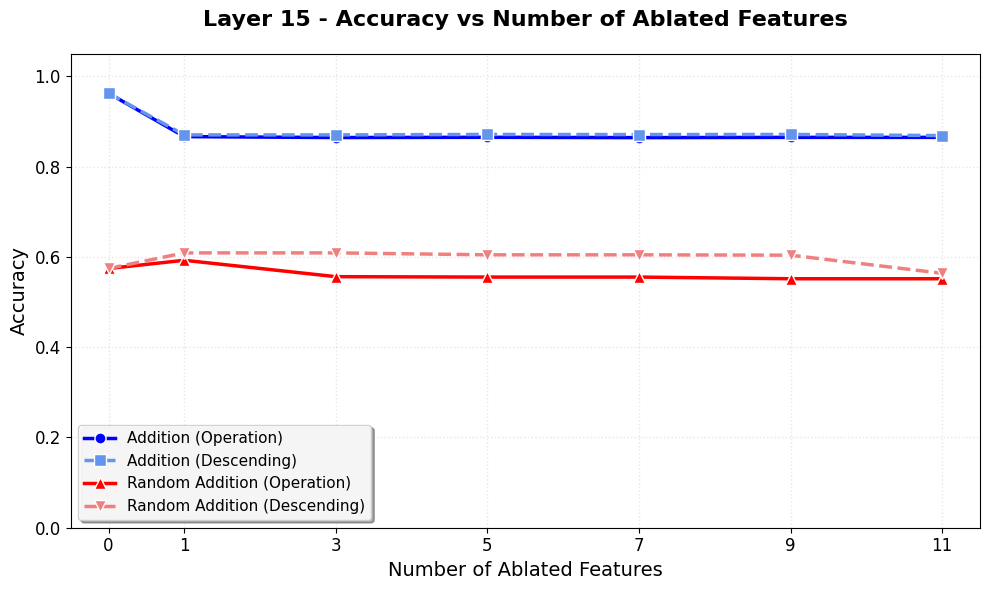

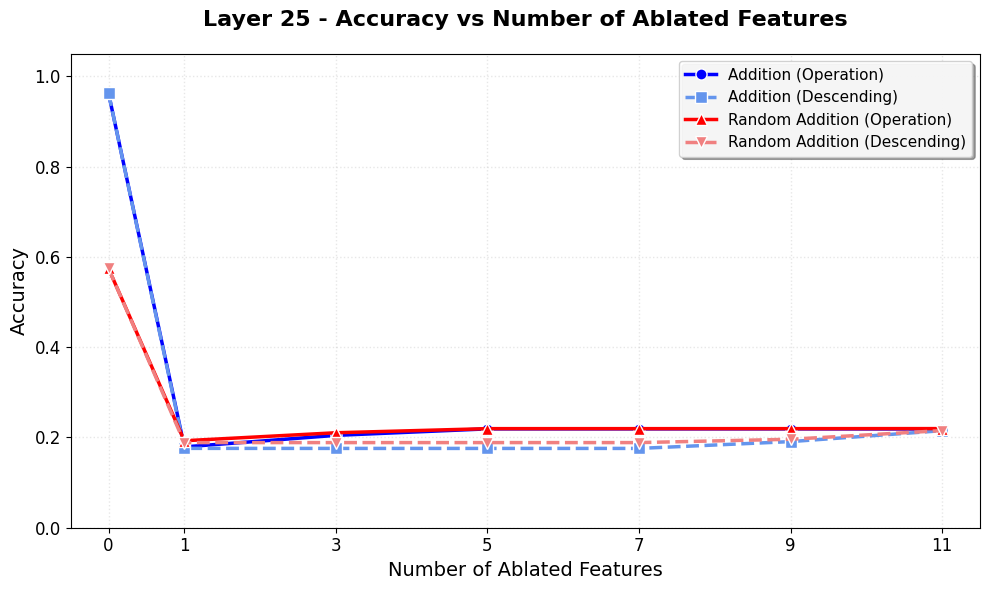

In [32]:
addition_descending_config = {
    ('addition', 'operation_ablation'): {'color': 'blue', 'linestyle': '-', 'marker': 'o', 'label': 'Addition (Operation)', 
                                         'name': 'Addition (Operation)', 'dash': 'solid', 'symbol': 'circle',
                                         'linewidth': 2.5, 'markersize': 8},
    ('addition_descending', 'operation_ablation'): {'color': 'cornflowerblue', 'linestyle': '--', 'marker': 's', 'label': 'Addition (Descending)',
                                    'name': 'Addition (Descending)', 'dash': 'dash', 'symbol': 'square',
                                    'linewidth': 2.5, 'markersize': 8},
    ('random_addition', 'operation_ablation'): {'color': 'red', 'linestyle': '-', 'marker': '^', 'label': 'Random Addition (Operation)',
                                                'name': 'Random Addition (Operation)', 'dash': 'solid', 'symbol': 'triangle-up',
                                                'linewidth': 2.5, 'markersize': 8},
    ('random_addition_descending', 'operation_ablation'): {'color': 'lightcoral', 'linestyle': '--', 'marker': 'v', 'label': 'Random Addition (Descending)',
                                           'name': 'Random Addition (Descending)', 'dash': 'dash', 'symbol': 'triangle-down',
                                           'linewidth': 2.5, 'markersize': 8}
}

# Generate the plots
plot_accuracy_by_features_per_layer(accuracy_results, addition_descending_config, layers=[0, 5, 10, 15, 25])
# Generate the interactive plots
plot_accuracy_by_features_interactive(accuracy_results, addition_descending_config, layers=[0, 5, 10, 15, 25])

plot_individual_layer_plots(accuracy_results, addition_descending_config, layers=[0, 5, 10, 15, 25])

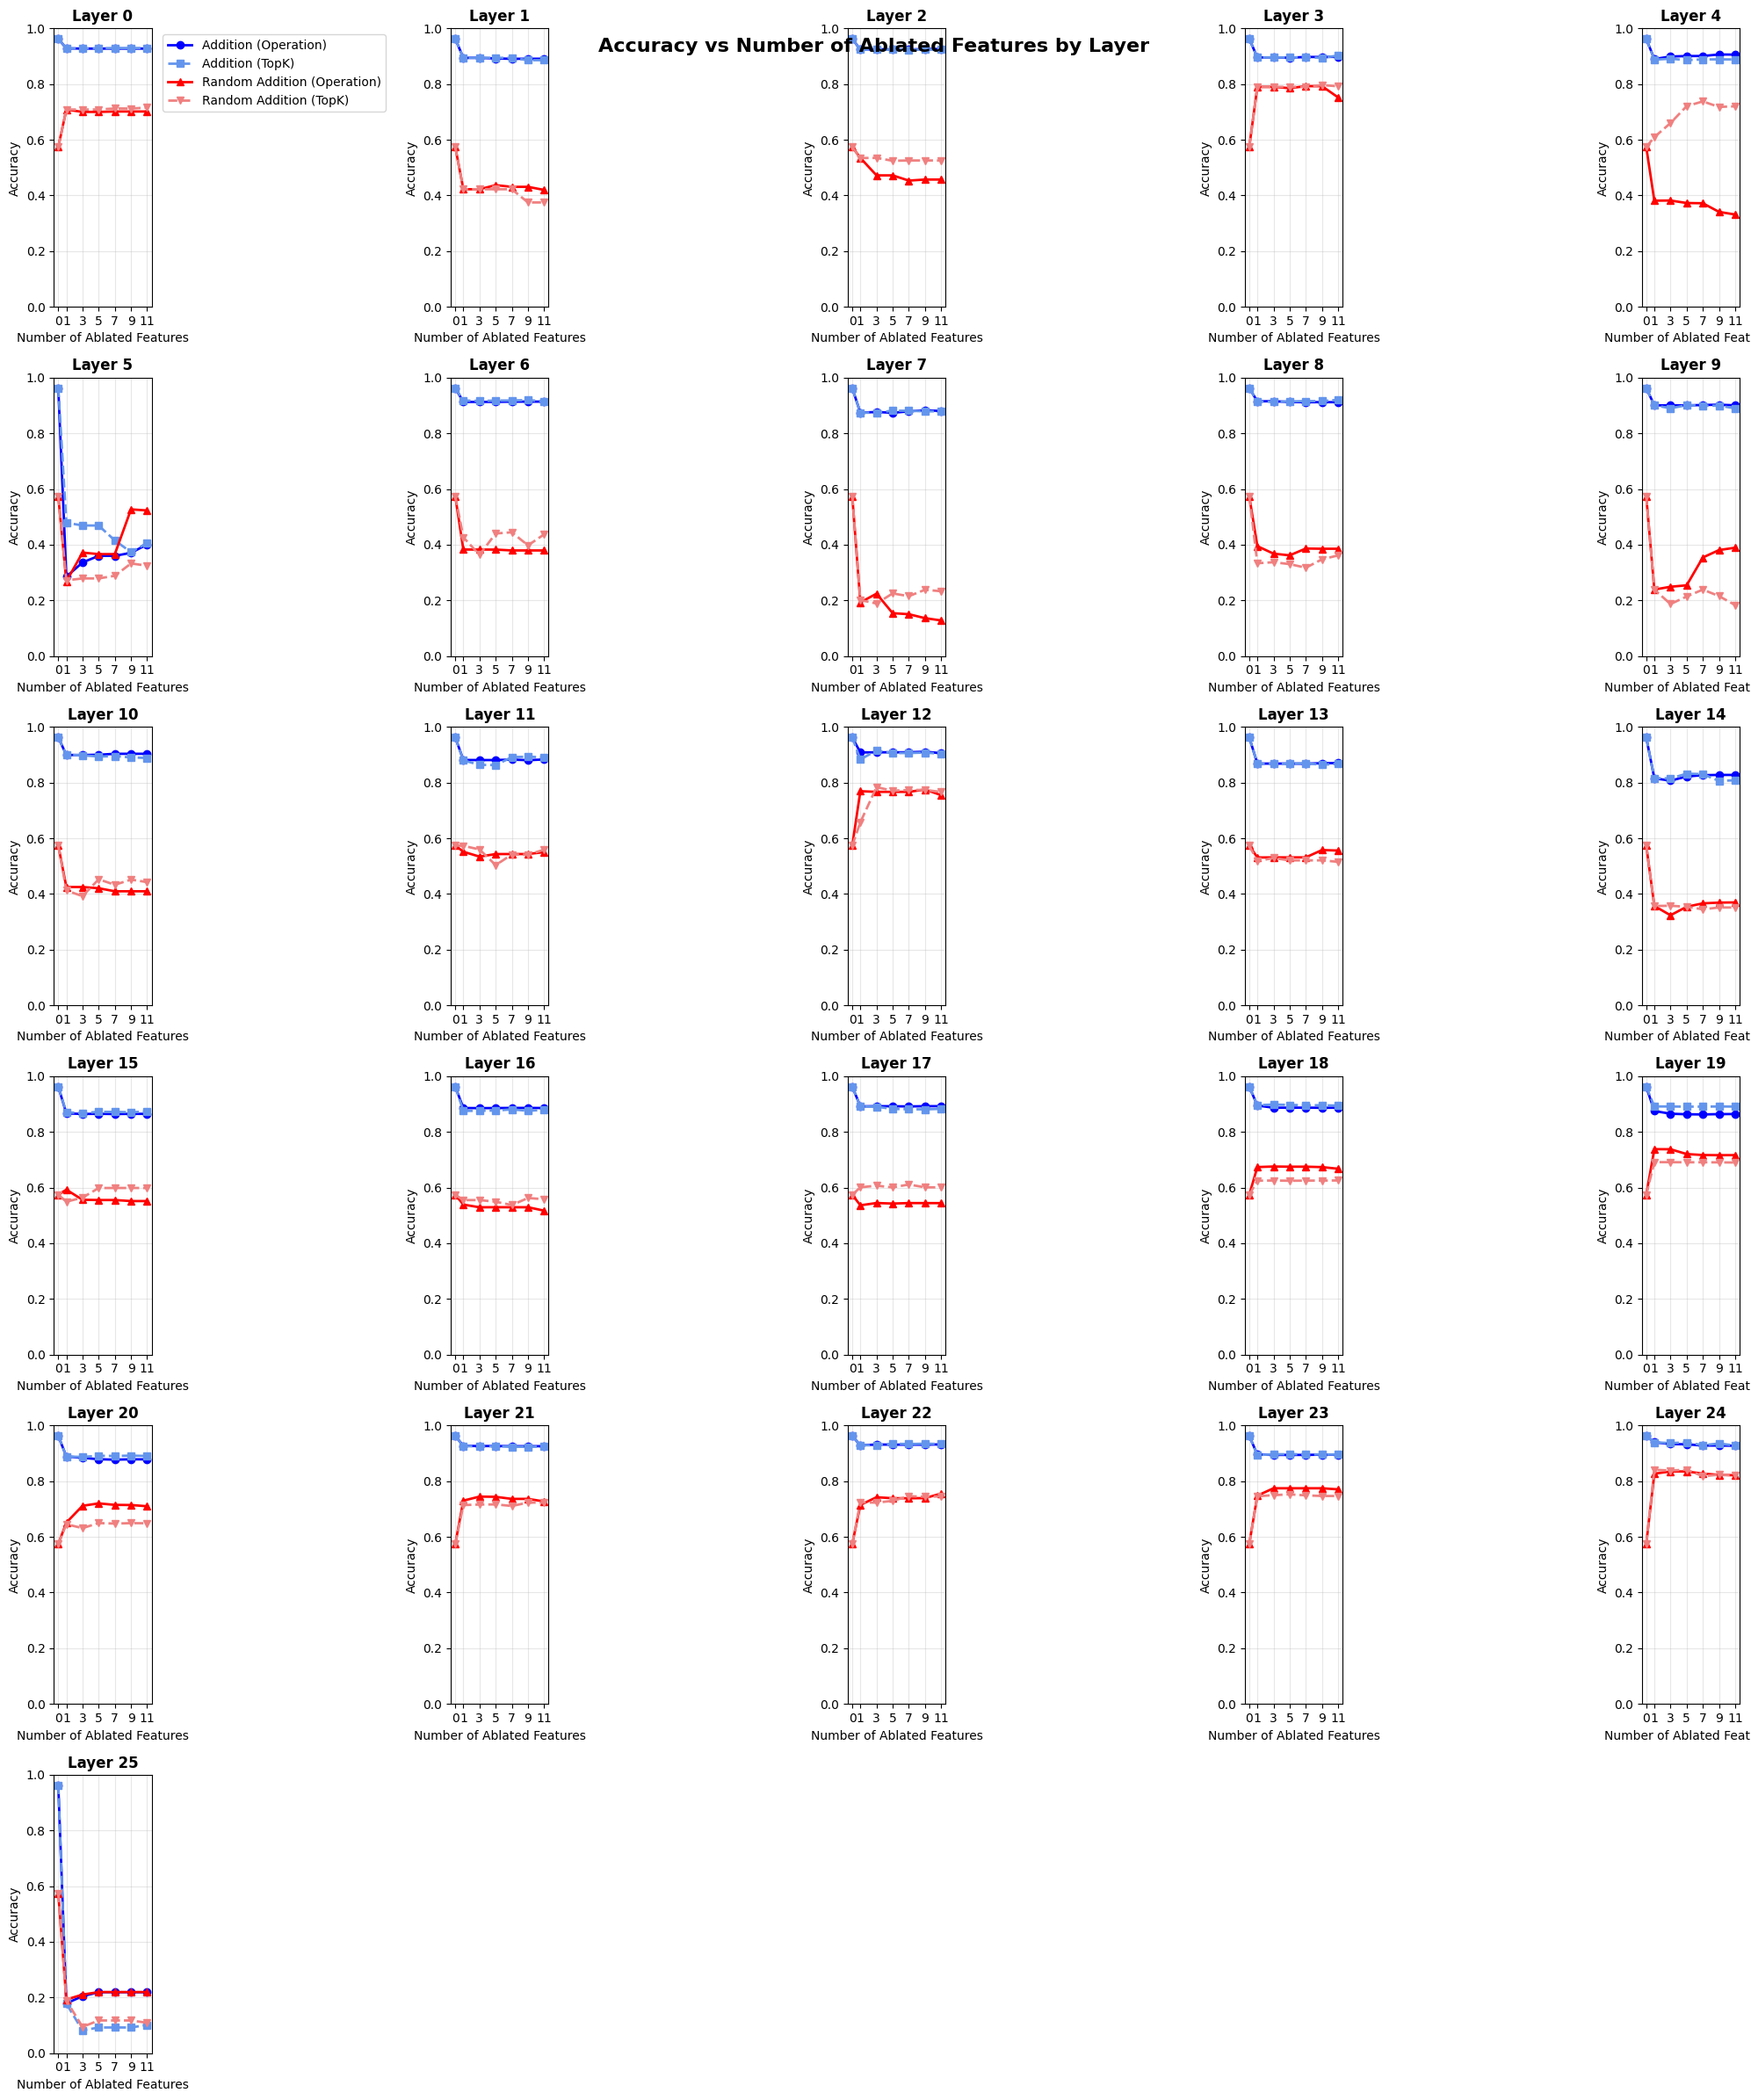

In [28]:
addition_config = {
    ('addition', 'operation_ablation'): {'color': 'blue', 'linestyle': '-', 'marker': 'o', 'label': 'Addition (Operation)', 
                                         'name': 'Addition (Operation)', 'dash': 'solid', 'symbol': 'circle',
                                         'linewidth': 2.5, 'markersize': 8},
    ('addition', 'topk_ablation'): {'color': 'cornflowerblue', 'linestyle': '--', 'marker': 's', 'label': 'Addition (TopK)',
                                    'name': 'Addition (TopK)', 'dash': 'dash', 'symbol': 'square',
                                    'linewidth': 2.5, 'markersize': 8},
    ('random_addition', 'operation_ablation'): {'color': 'red', 'linestyle': '-', 'marker': '^', 'label': 'Random Addition (Operation)',
                                                'name': 'Random Addition (Operation)', 'dash': 'solid', 'symbol': 'triangle-up',
                                                'linewidth': 2.5, 'markersize': 8},
    ('random_addition', 'topk_ablation'): {'color': 'lightcoral', 'linestyle': '--', 'marker': 'v', 'label': 'Random Addition (TopK)',
                                           'name': 'Random Addition (TopK)', 'dash': 'dash', 'symbol': 'triangle-down',
                                           'linewidth': 2.5, 'markersize': 8}
}

# Generate the plots
plot_accuracy_by_features_per_layer(accuracy_results, addition_config)
# Generate the interactive plots
plot_accuracy_by_features_interactive(accuracy_results, addition_config)

Generating individual plots for each layer...
Note: This will create 26 separate plots, one for each layer.


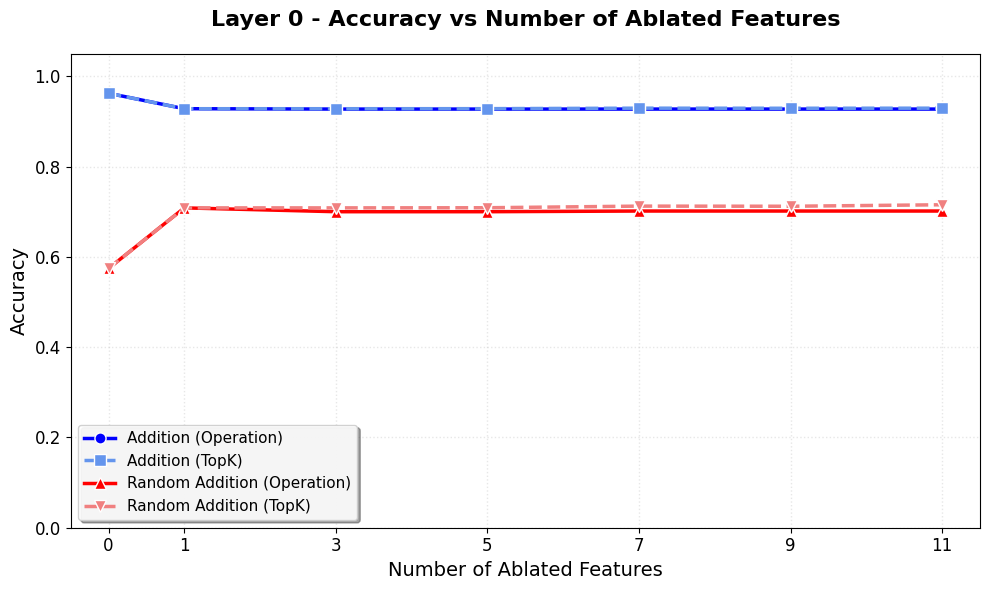

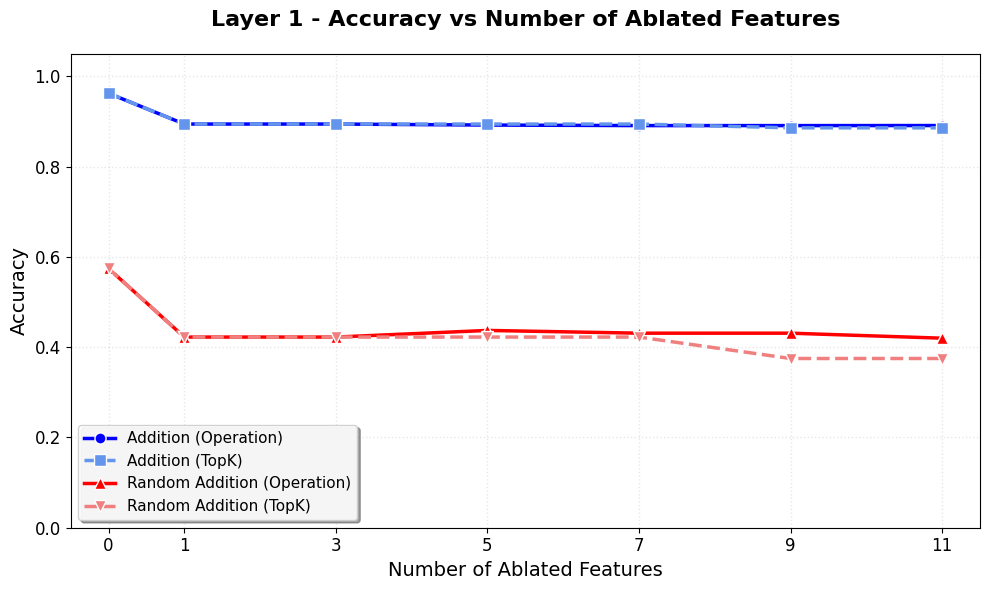

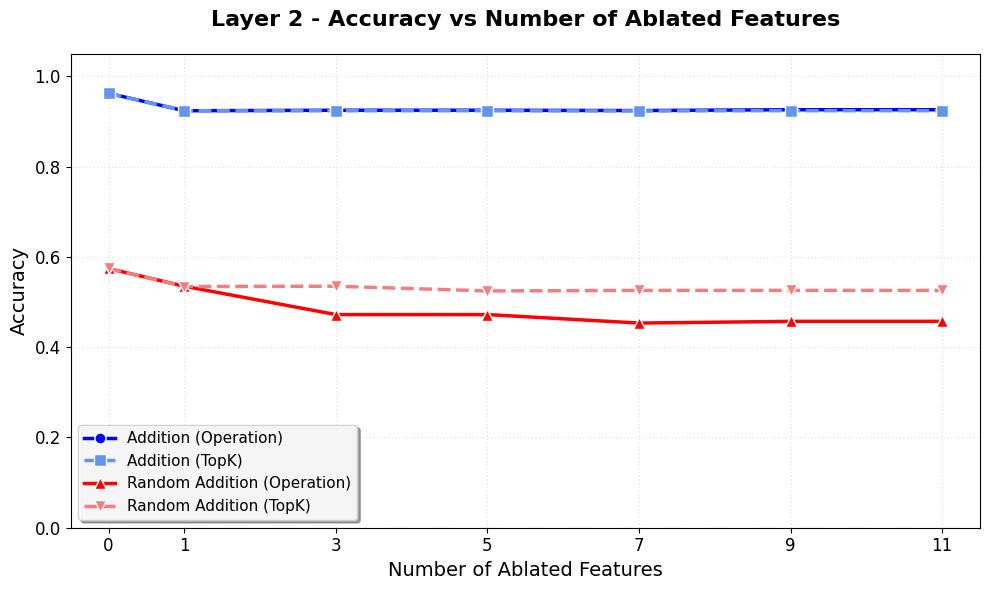

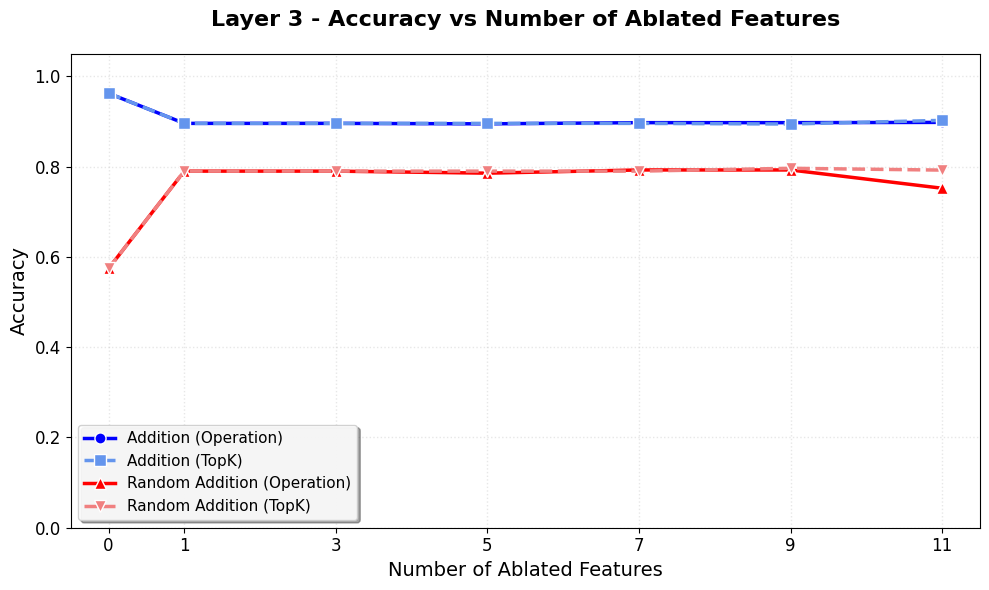

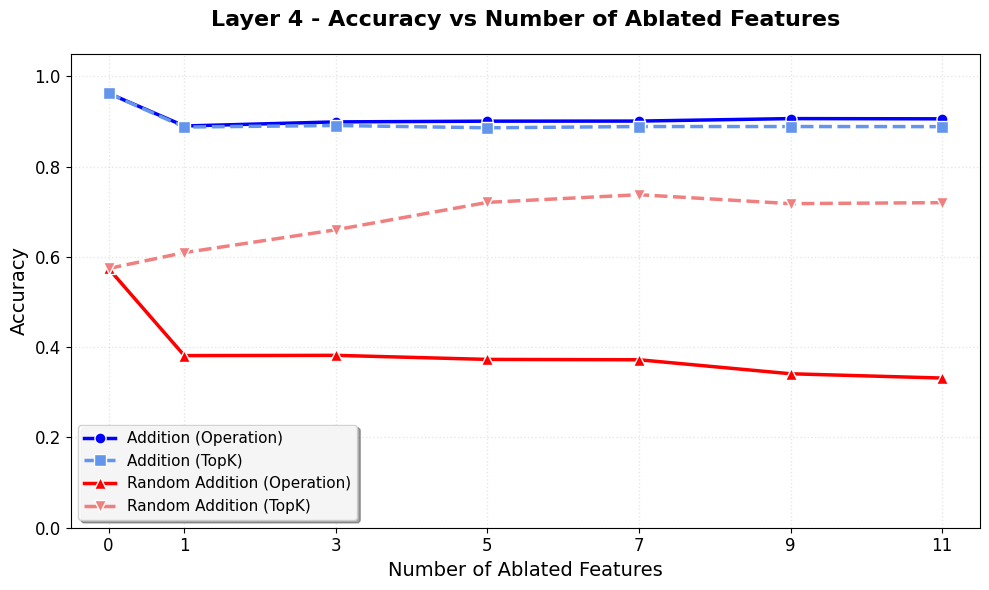

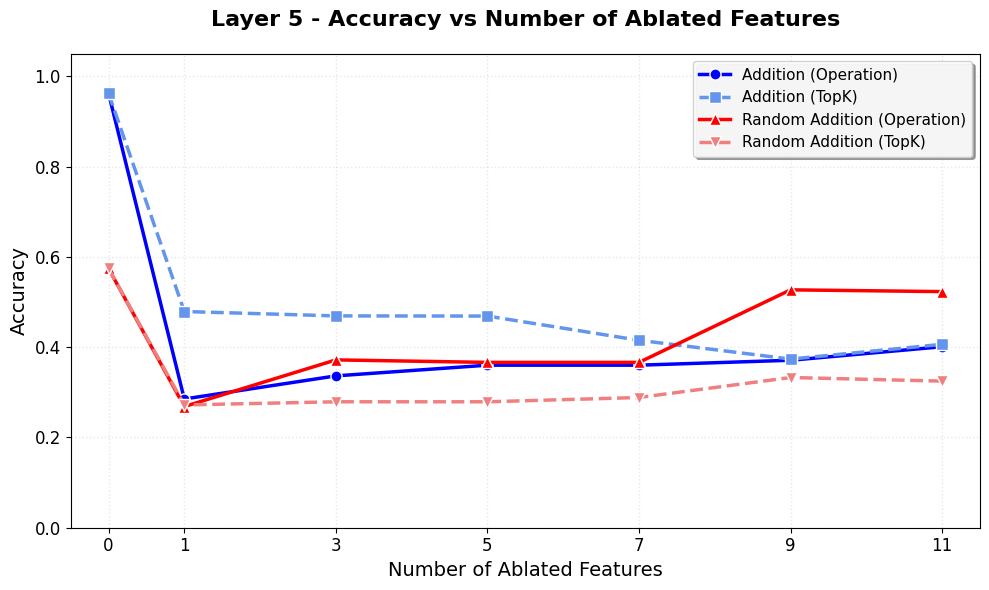

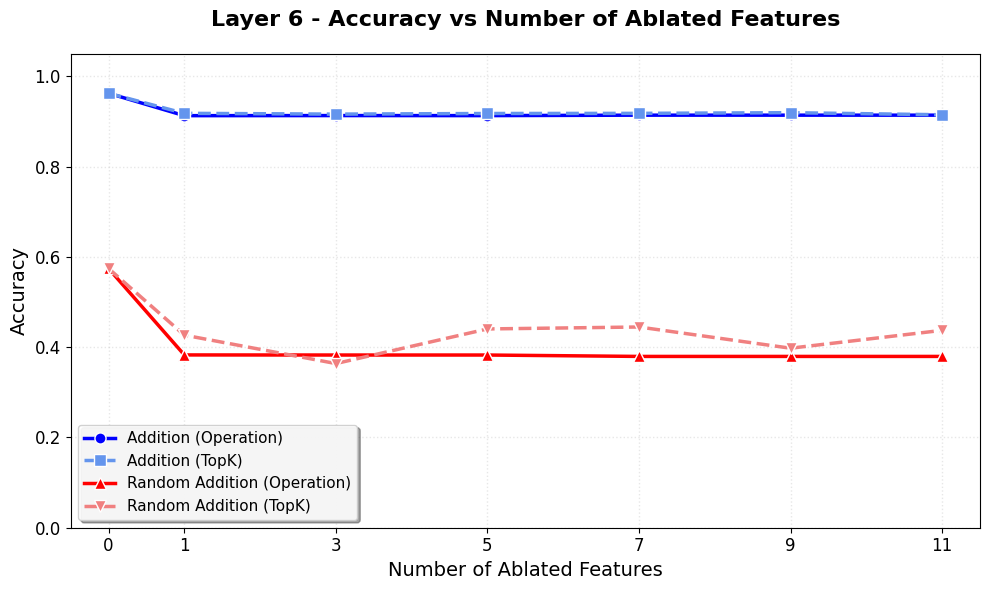

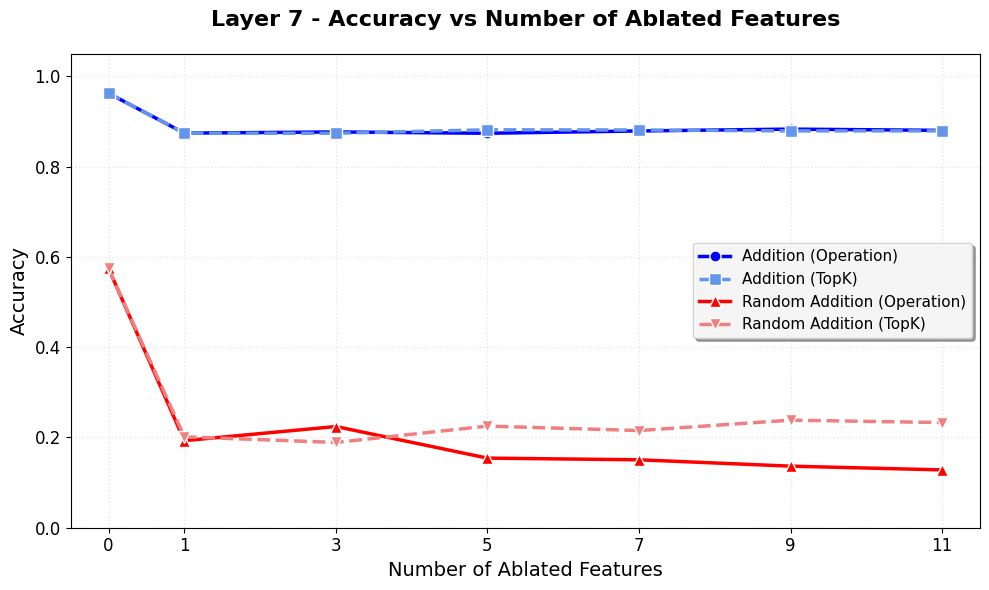

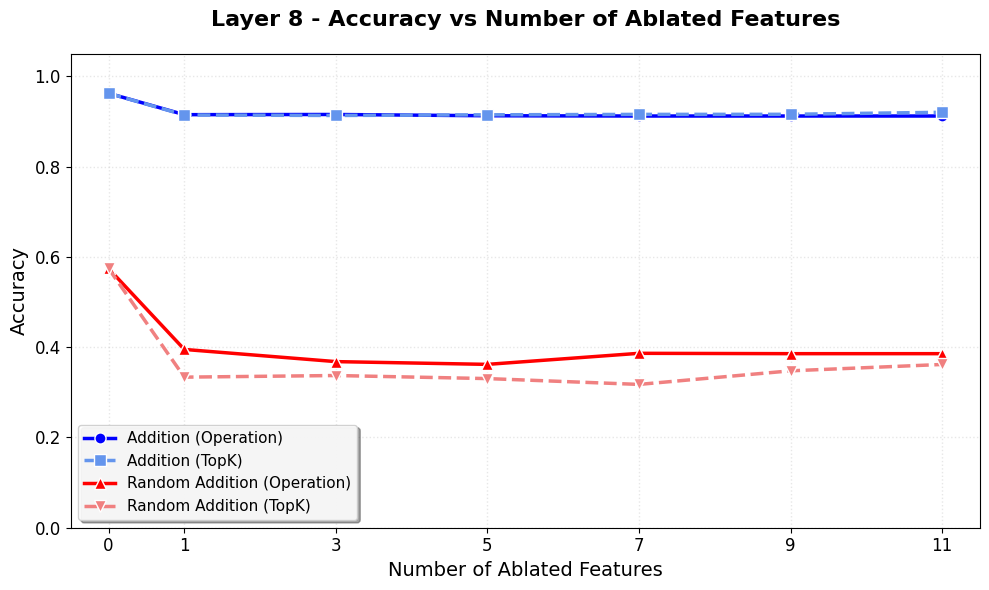

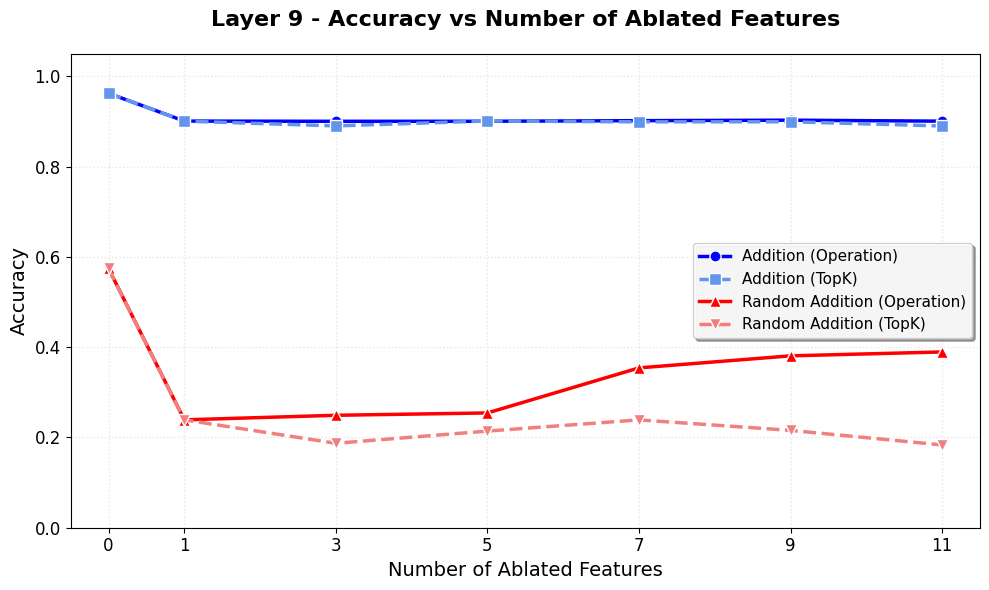

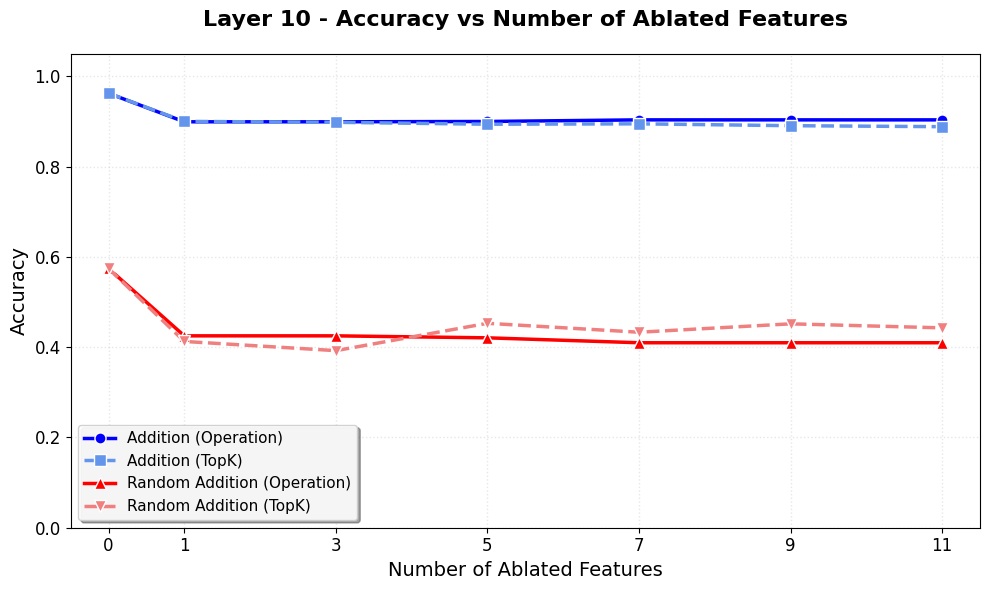

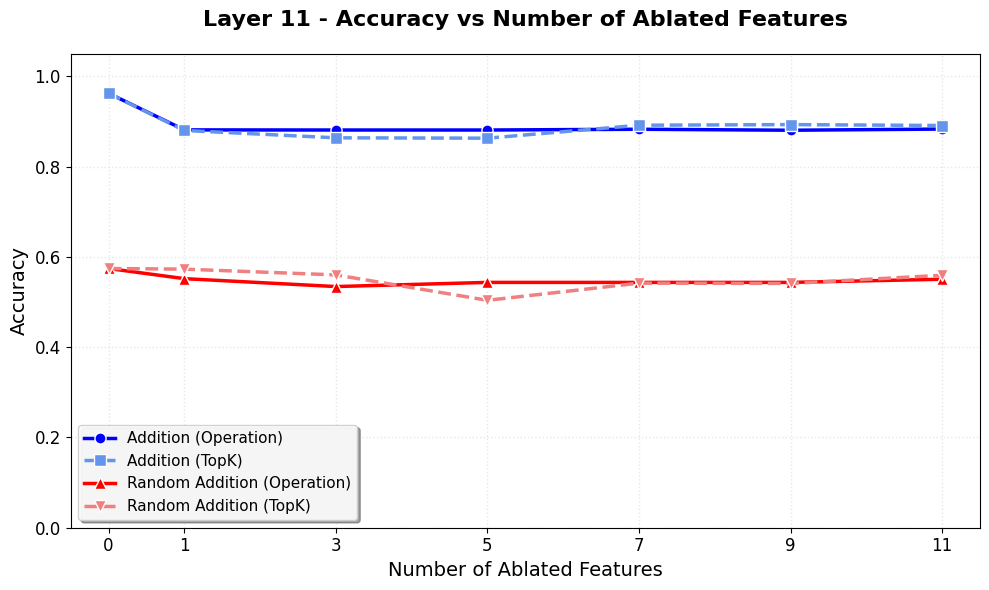

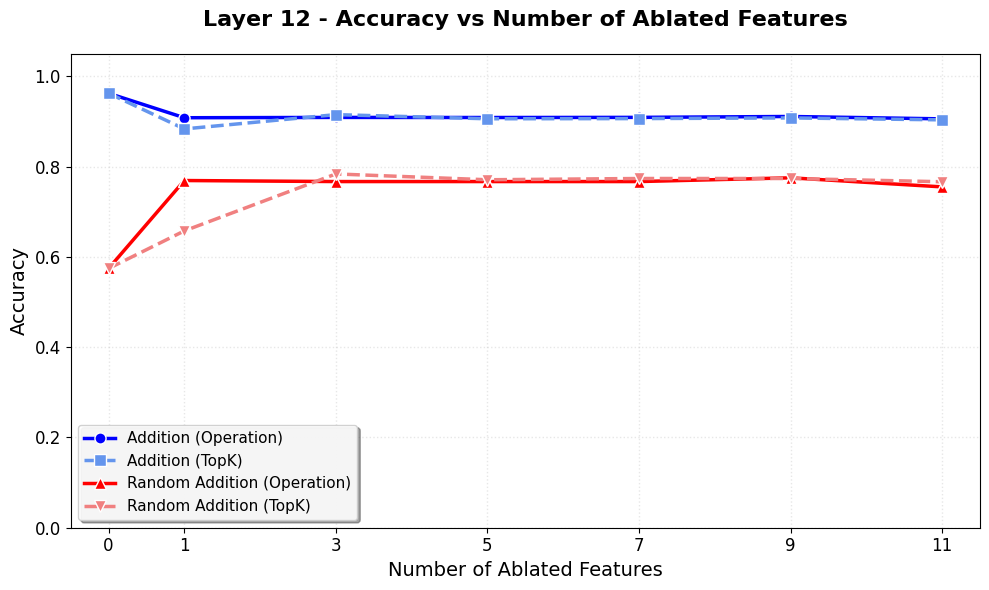

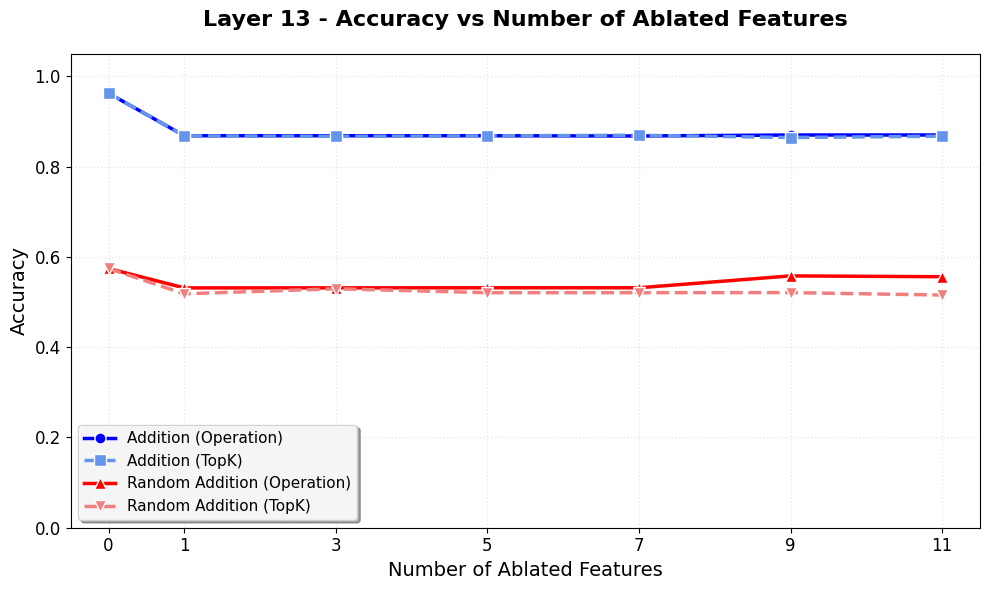

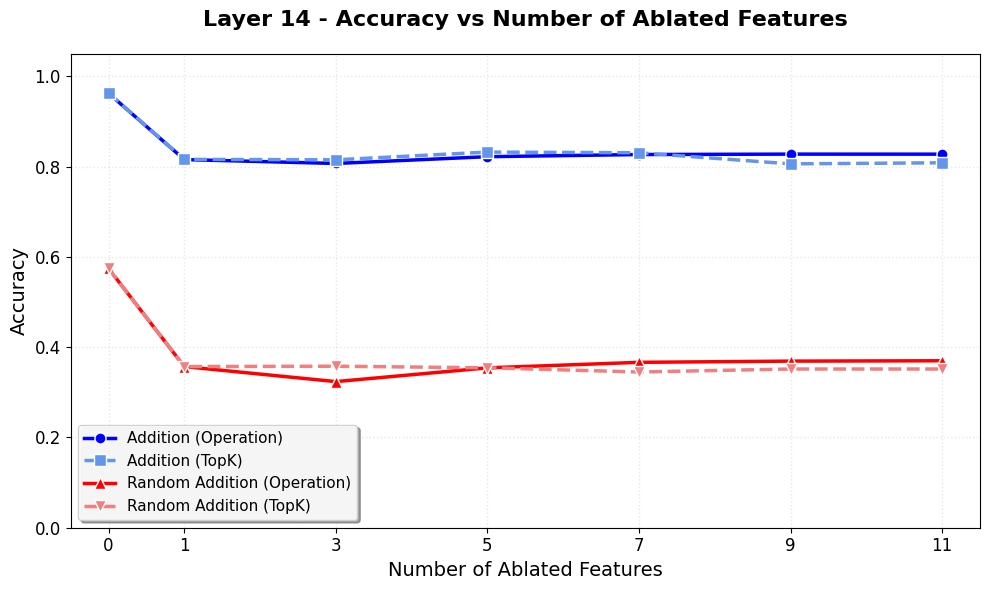

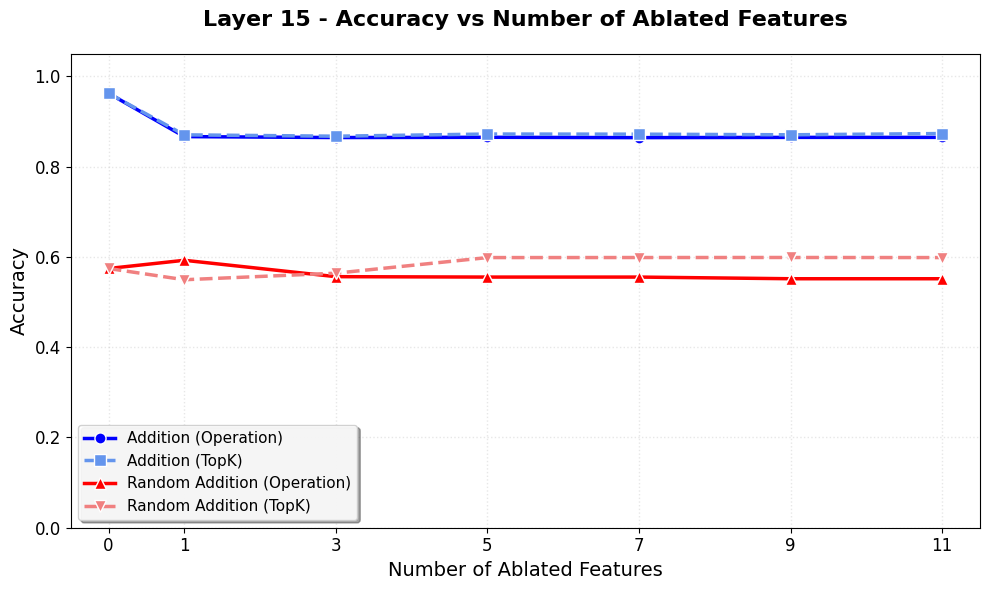

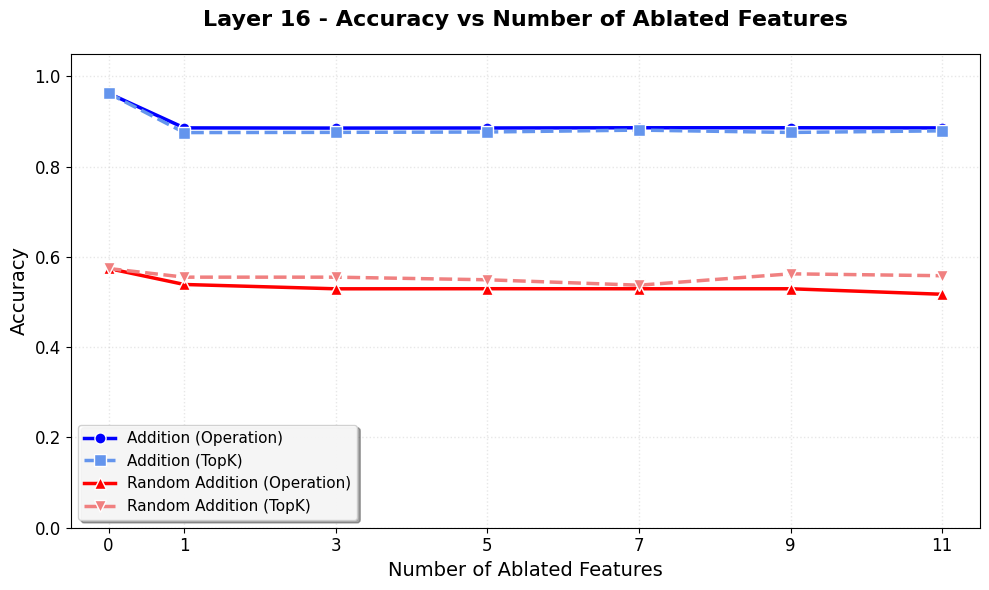

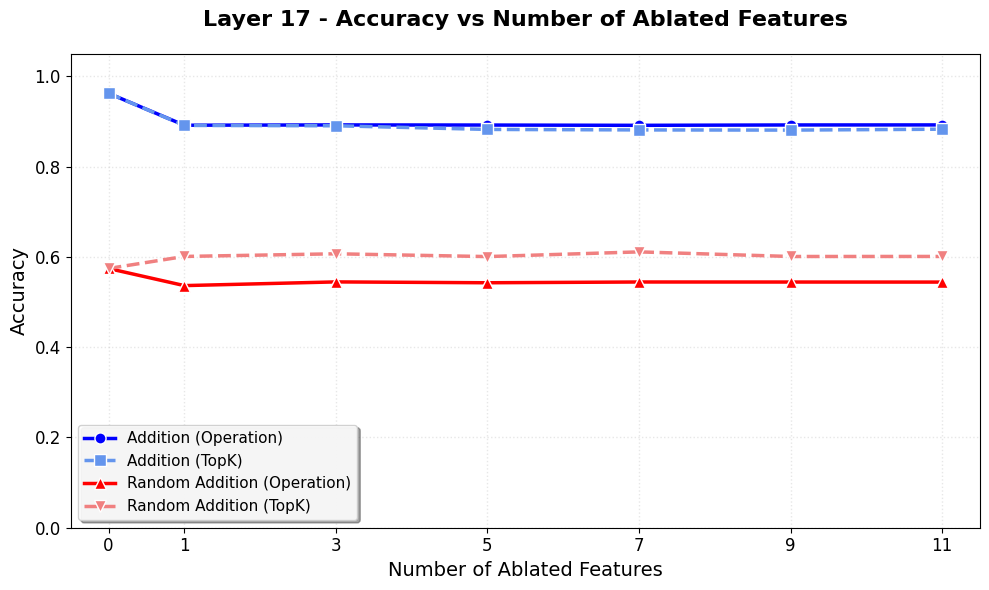

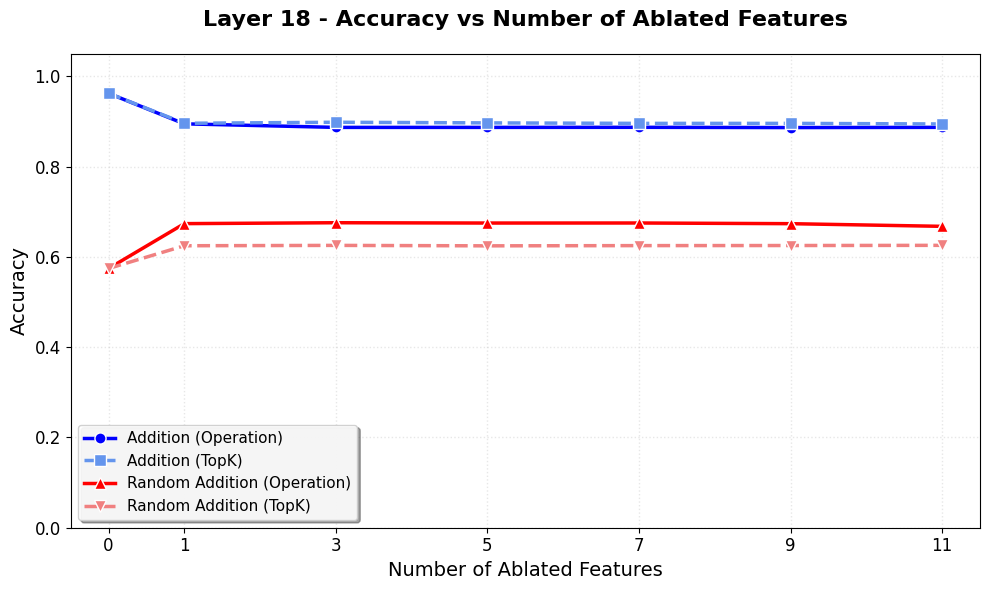

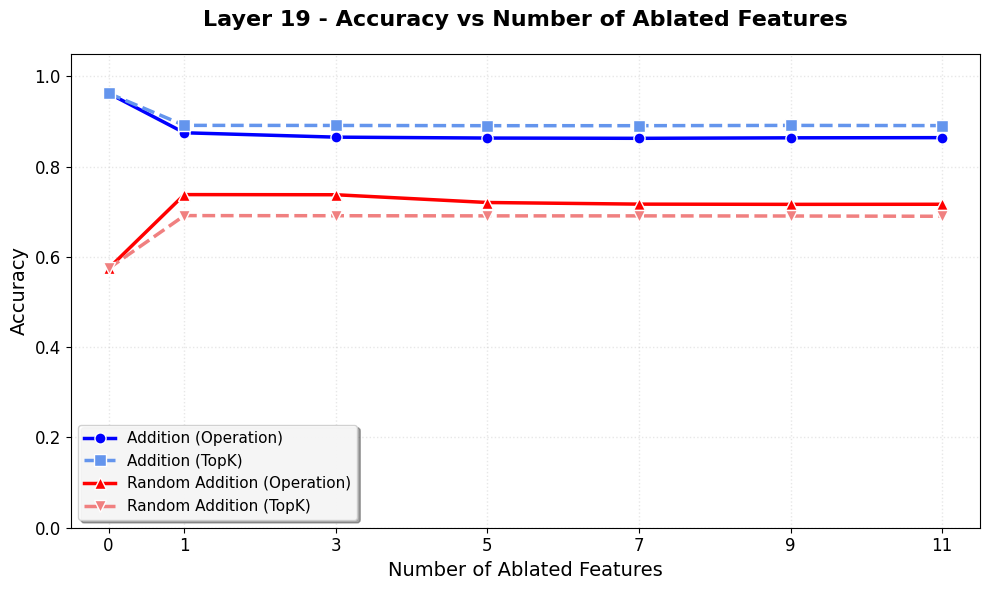

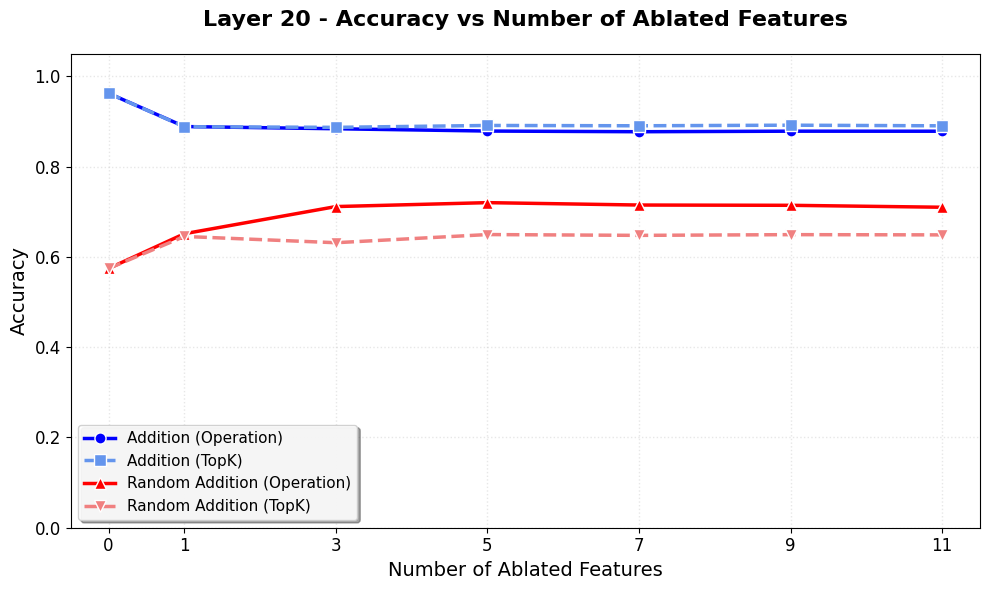

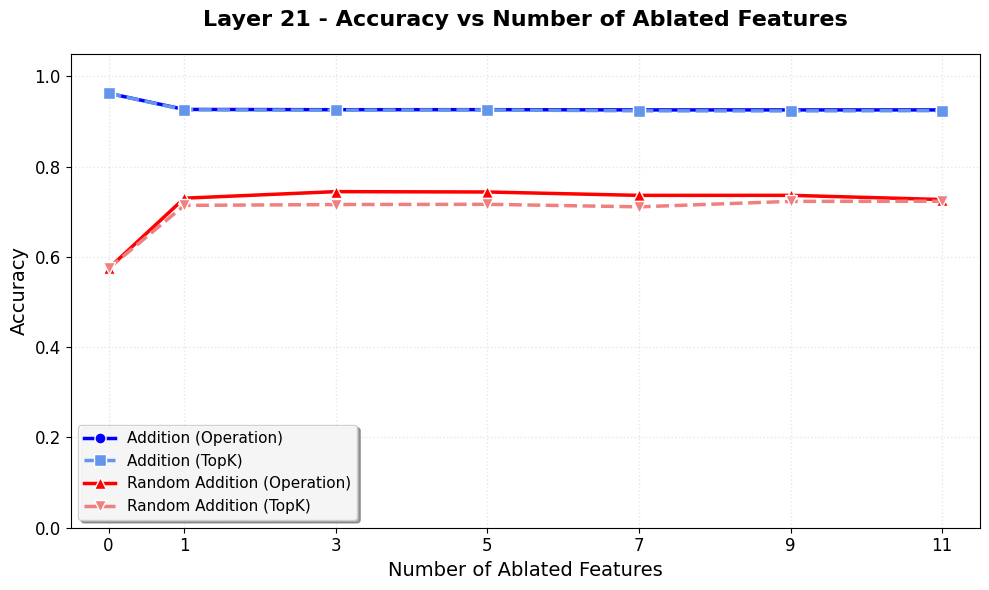

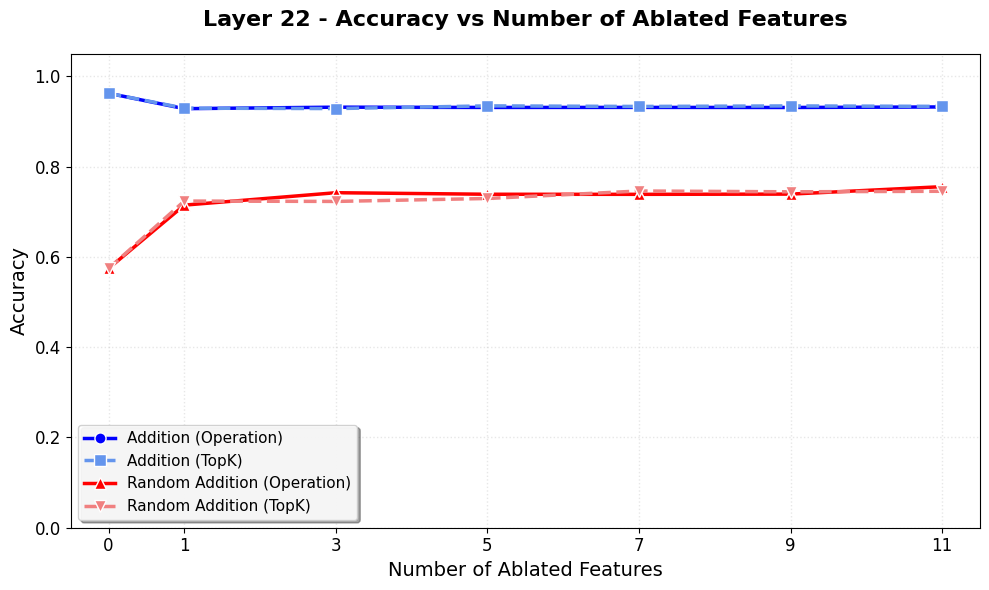

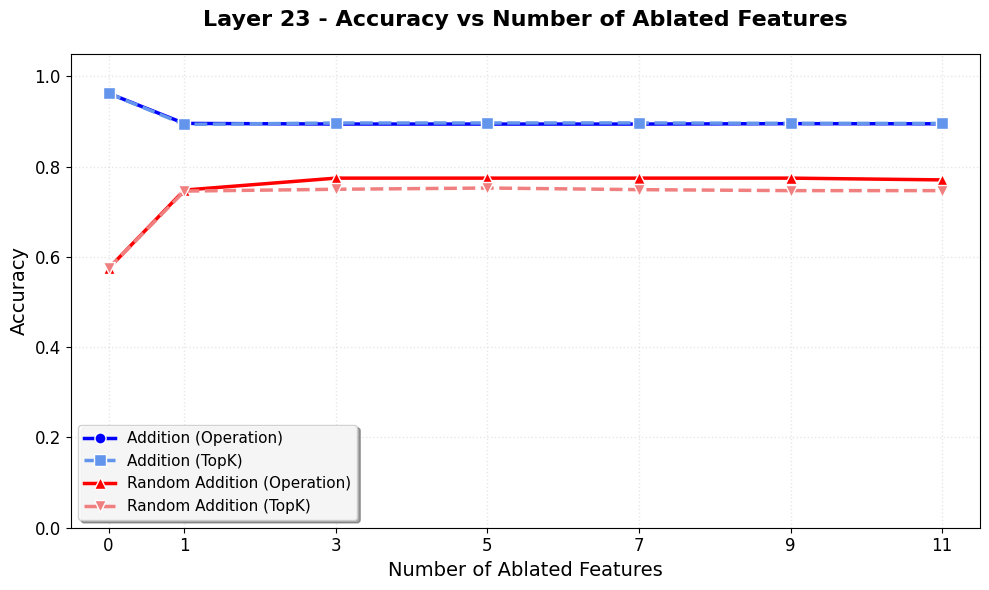

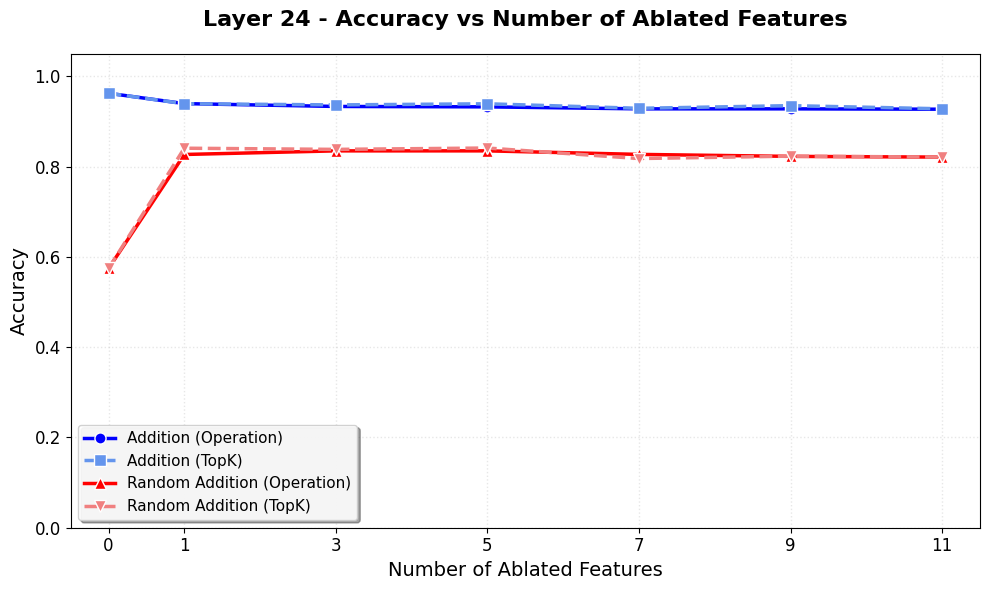

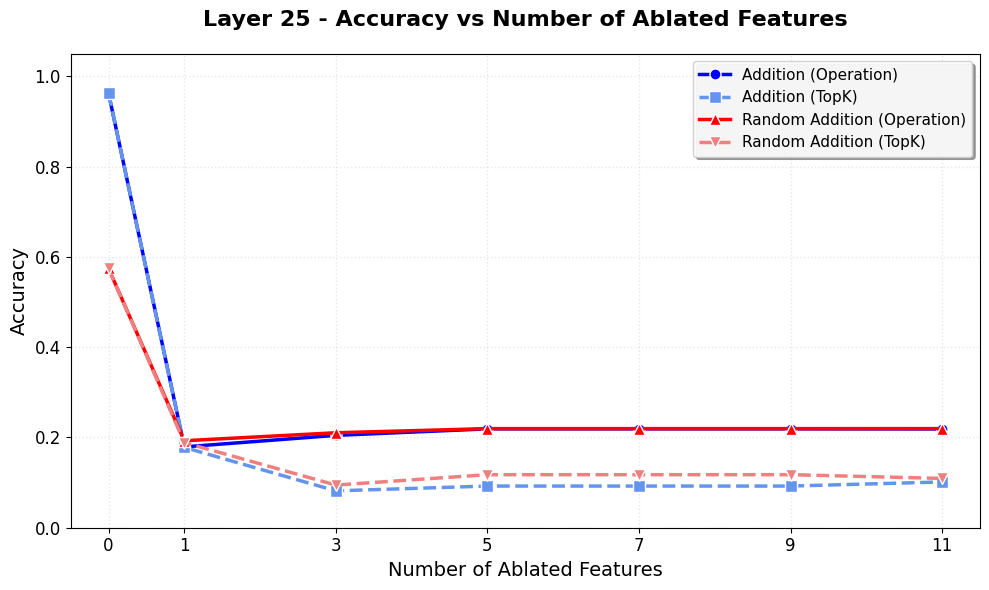

In [8]:

# Generate individual plots for each layer
print("Generating individual plots for each layer...")
print("Note: This will create 26 separate plots, one for each layer.")
plot_individual_layer_plots(accuracy_results, addition_config)

Generating individual plots for each layer...
Note: This will create 26 separate plots, one for each layer.


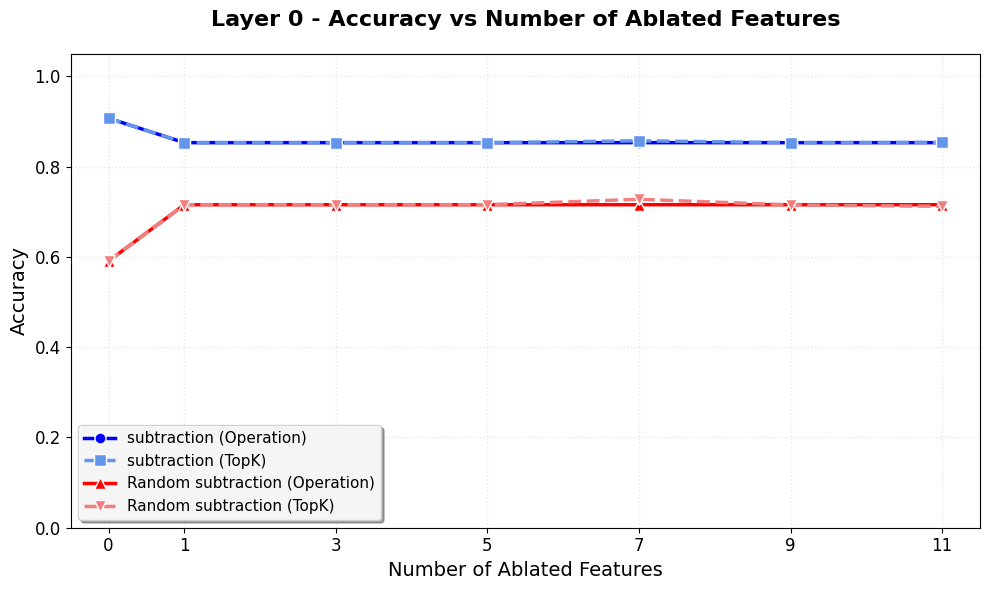

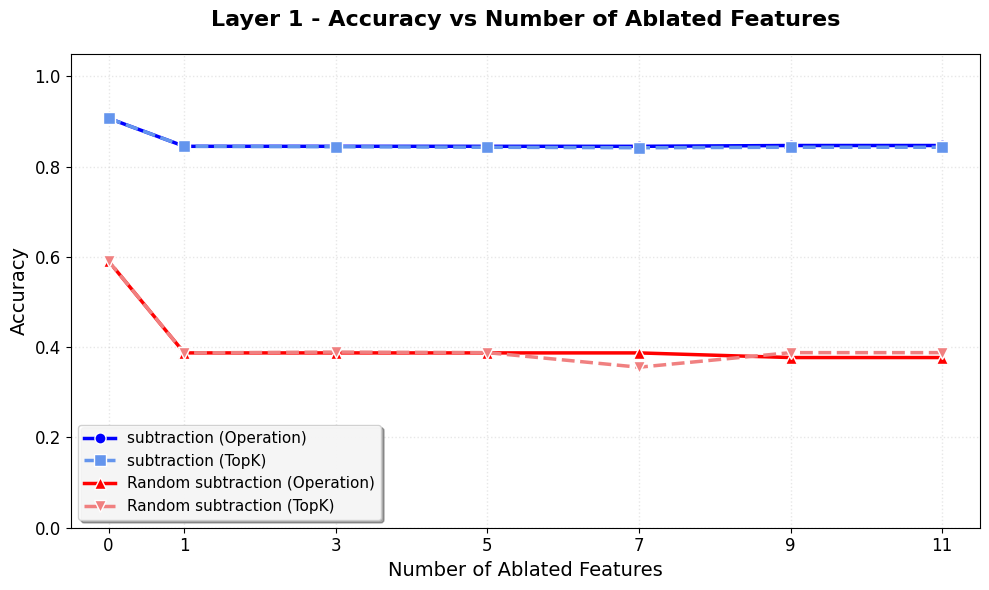

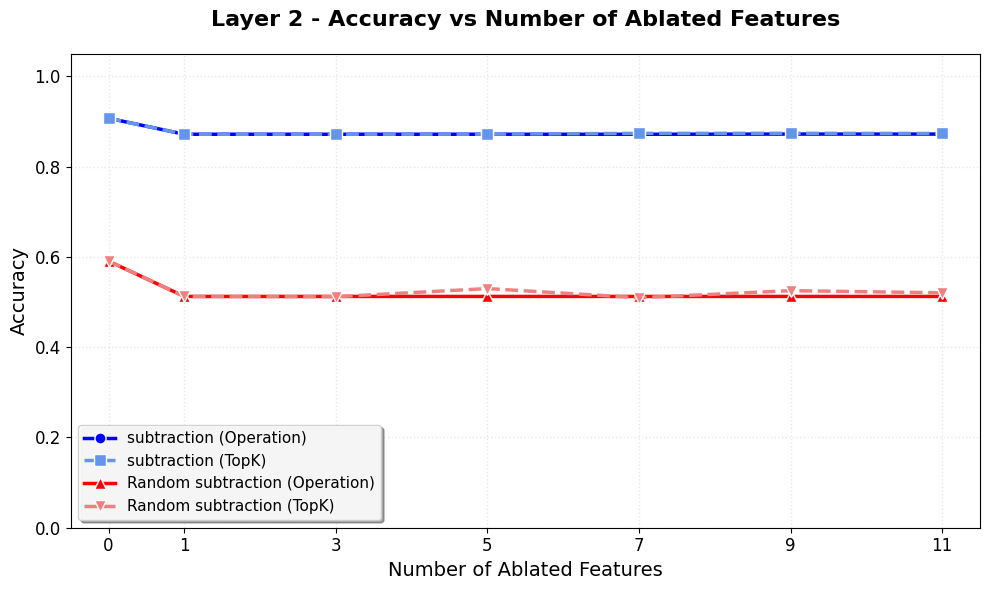

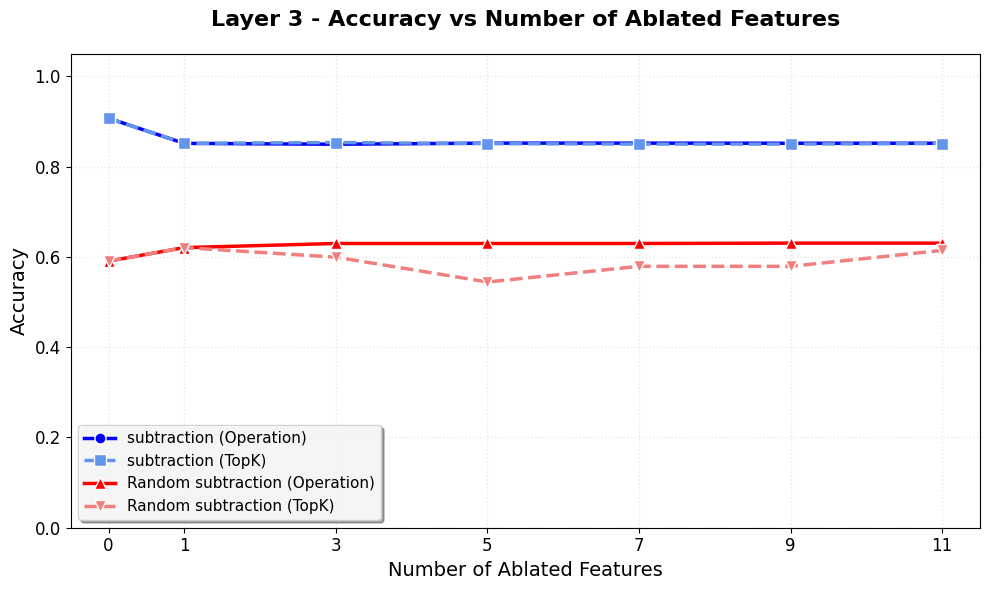

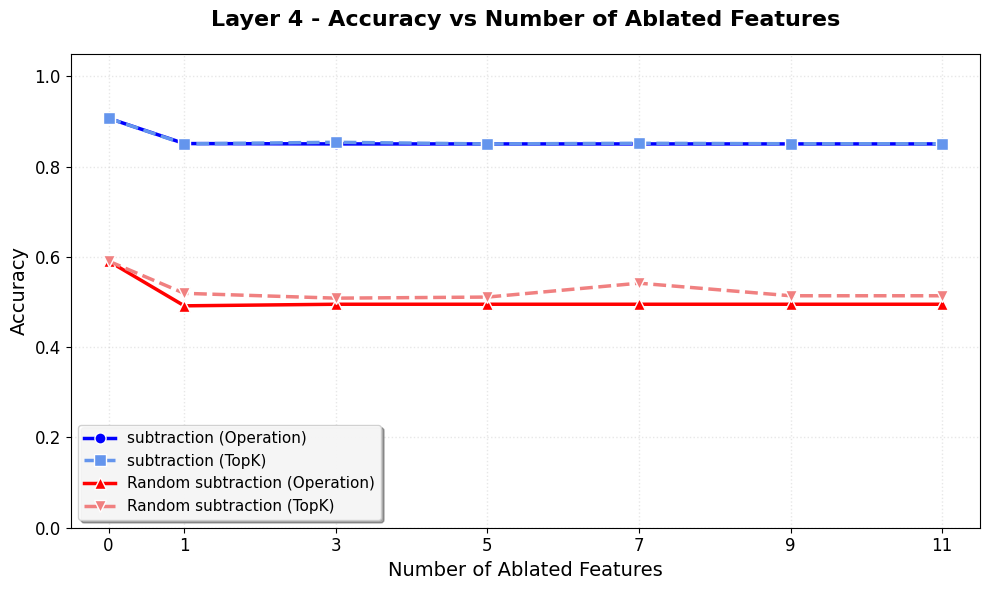

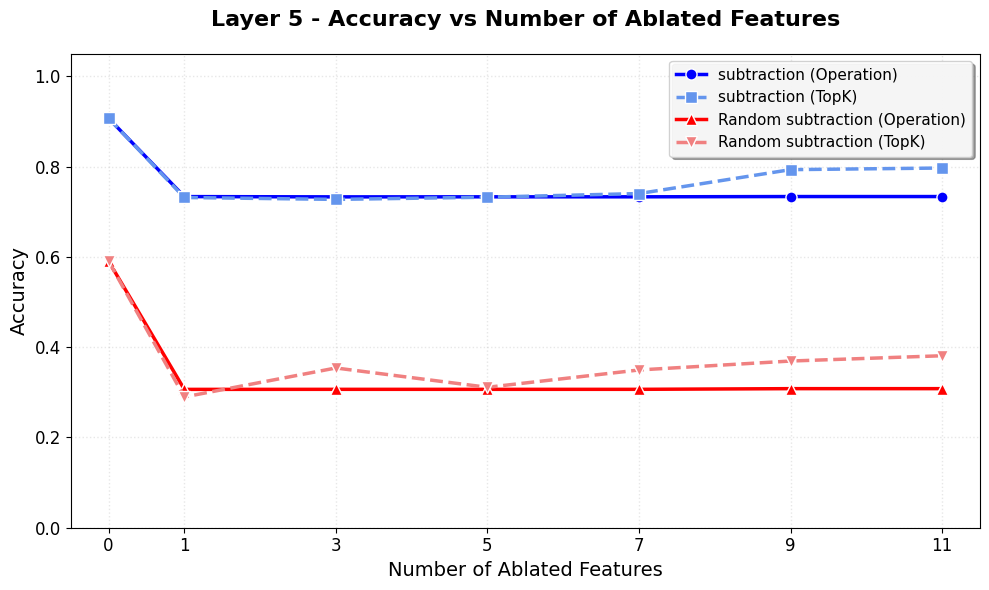

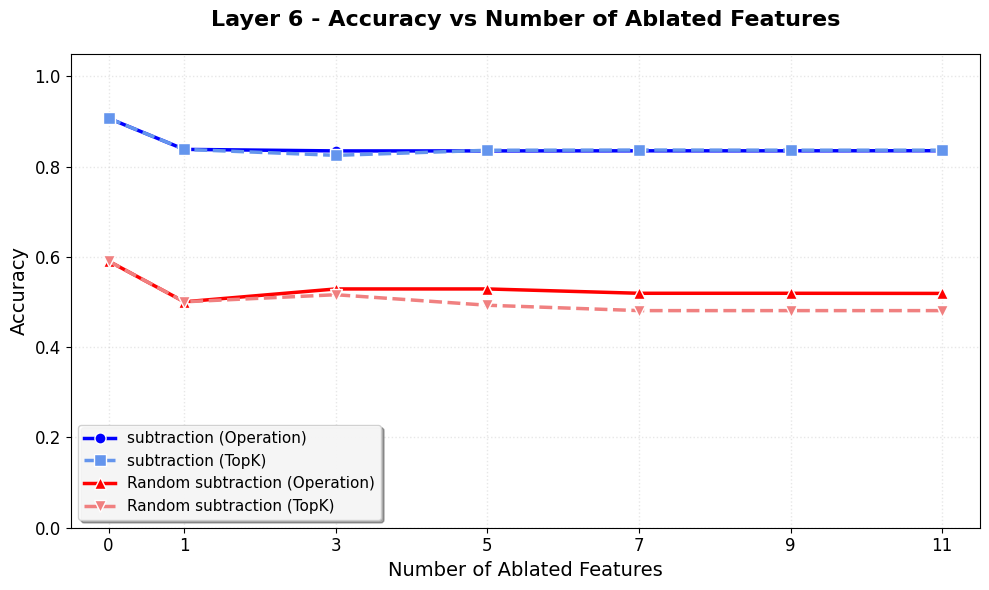

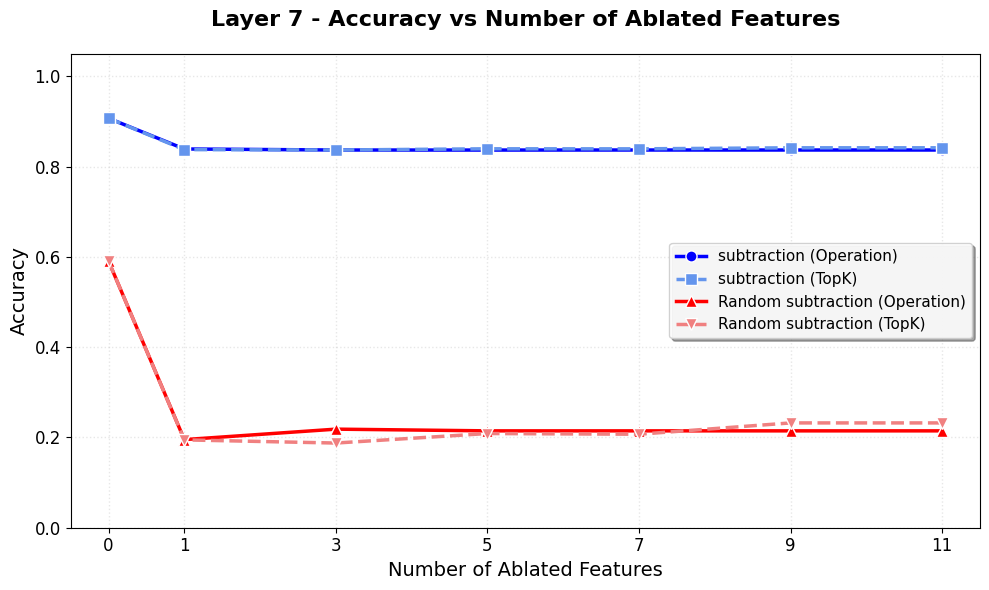

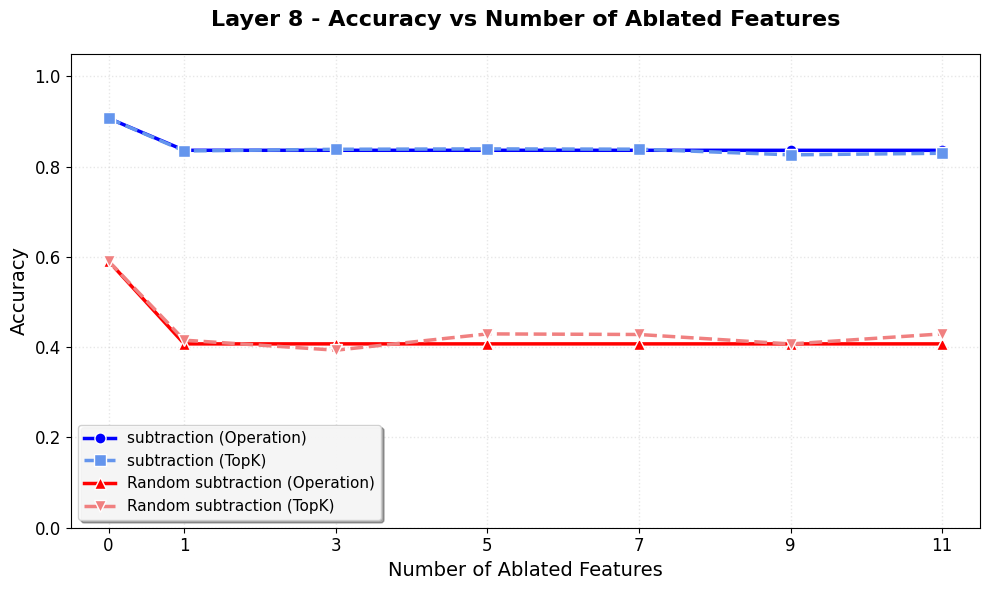

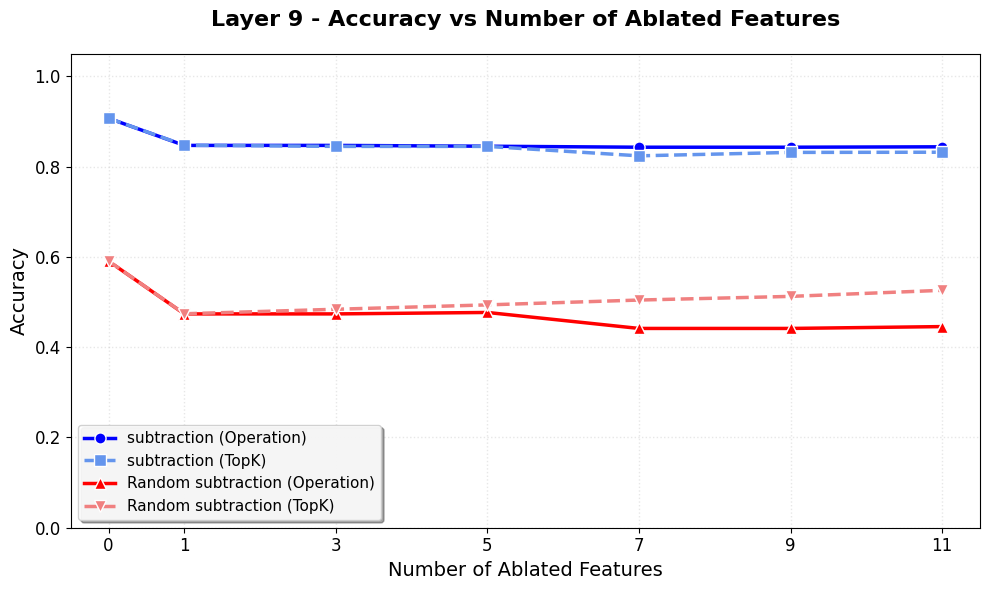

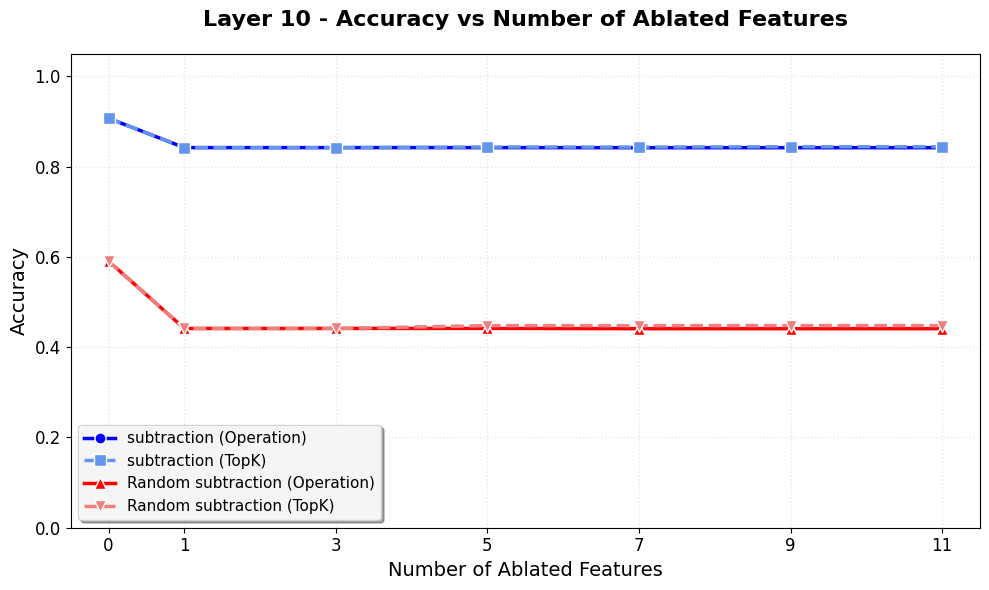

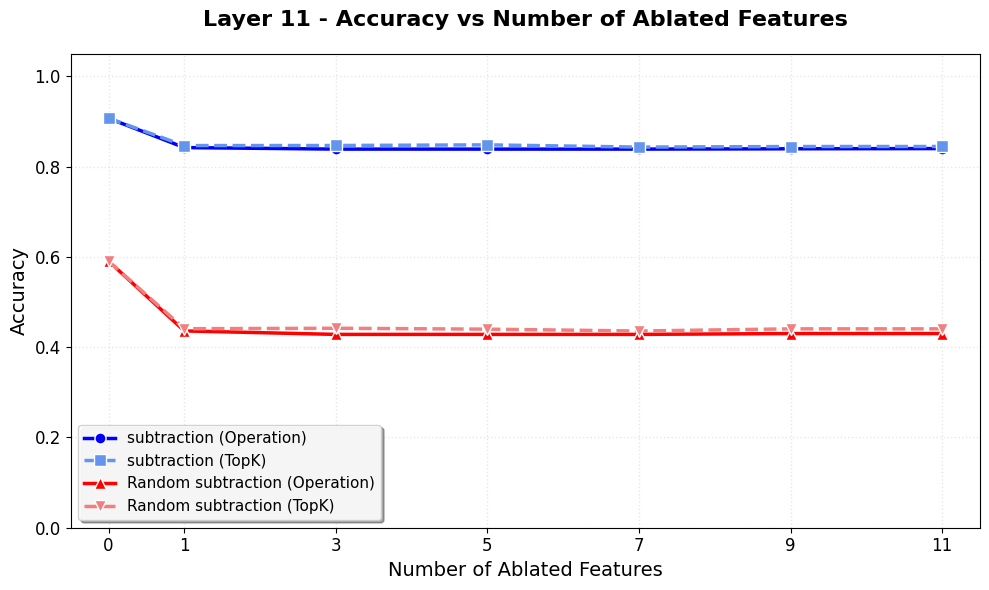

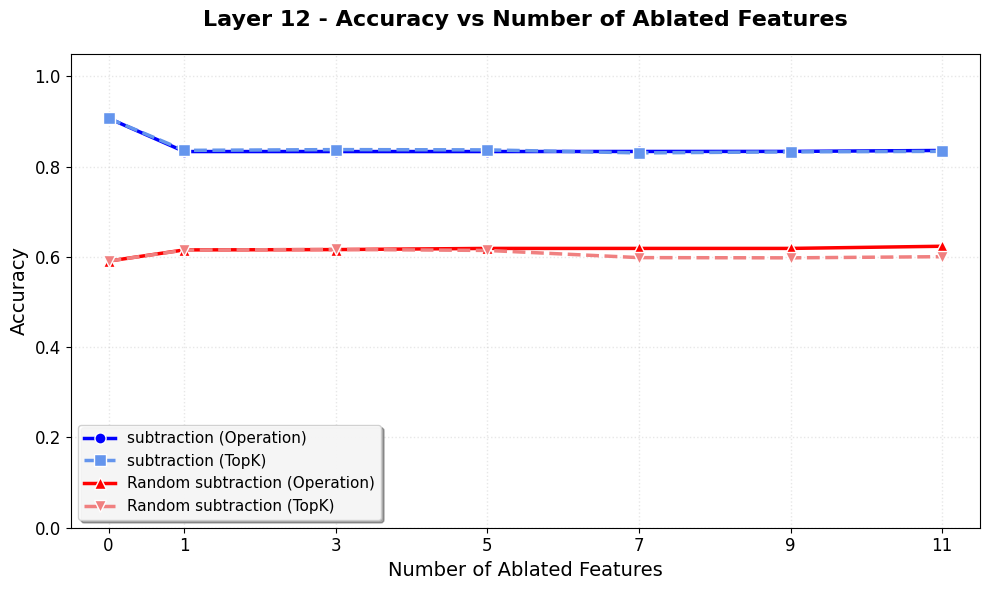

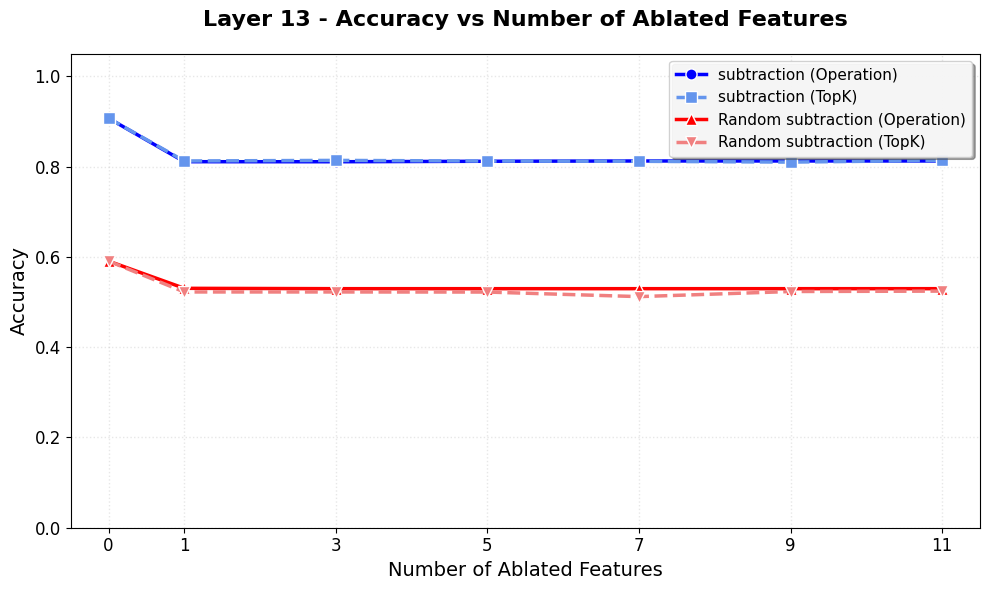

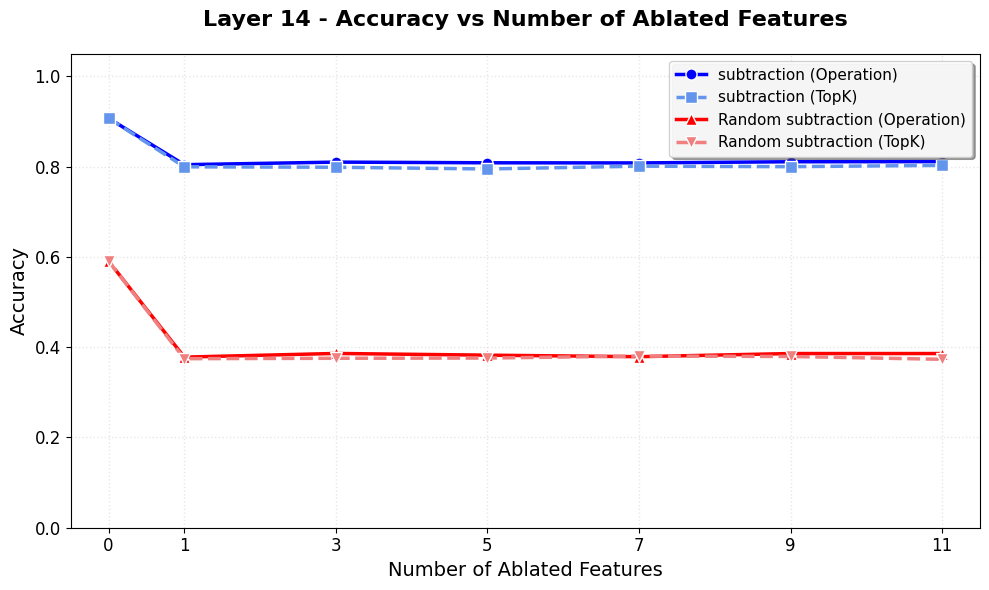

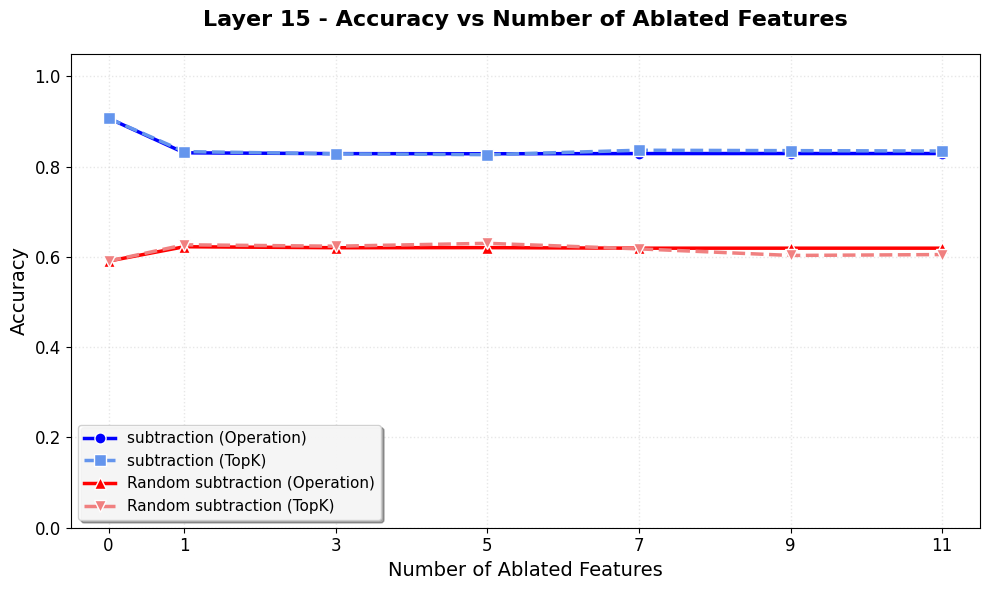

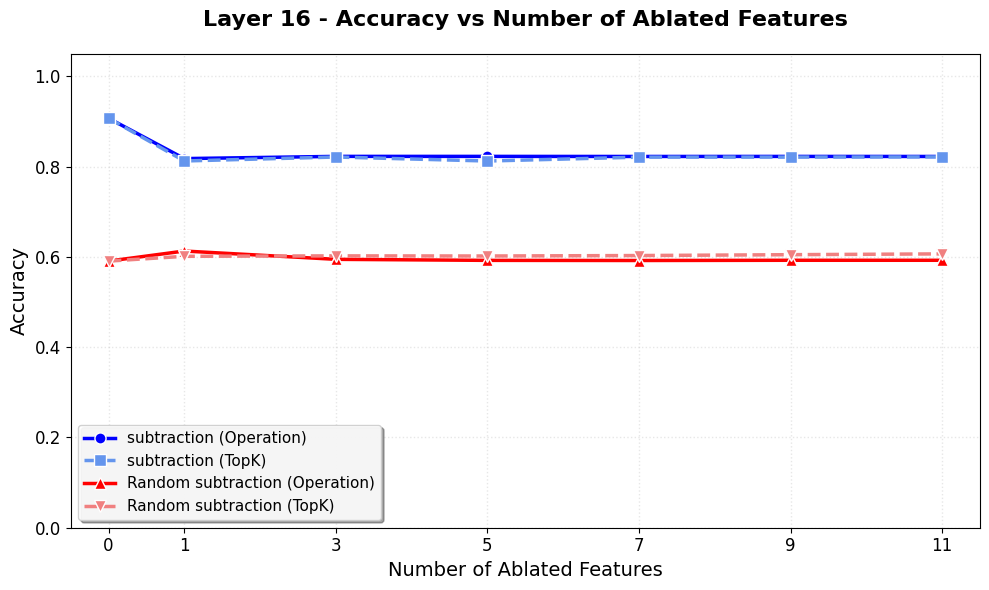

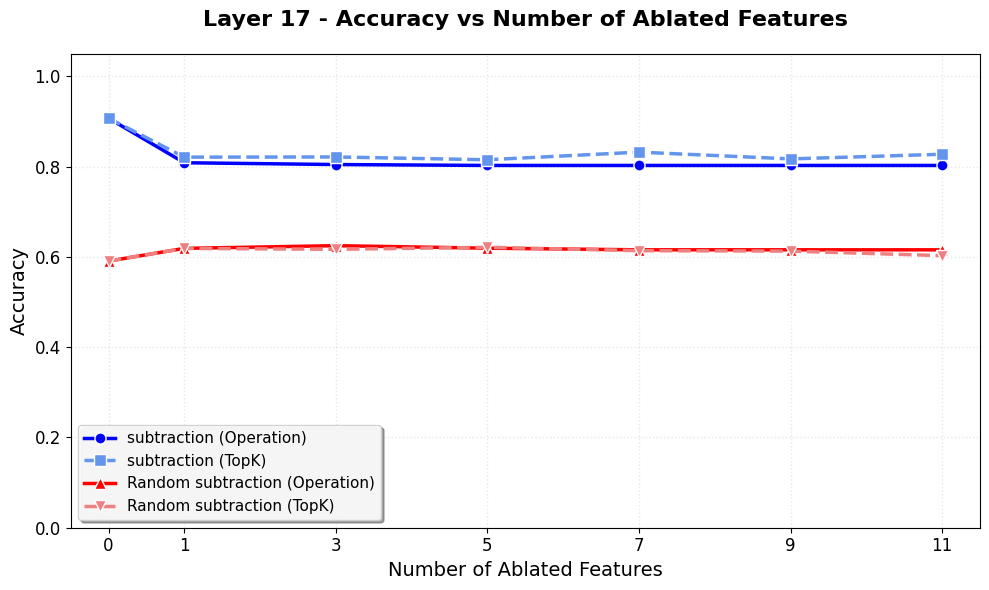

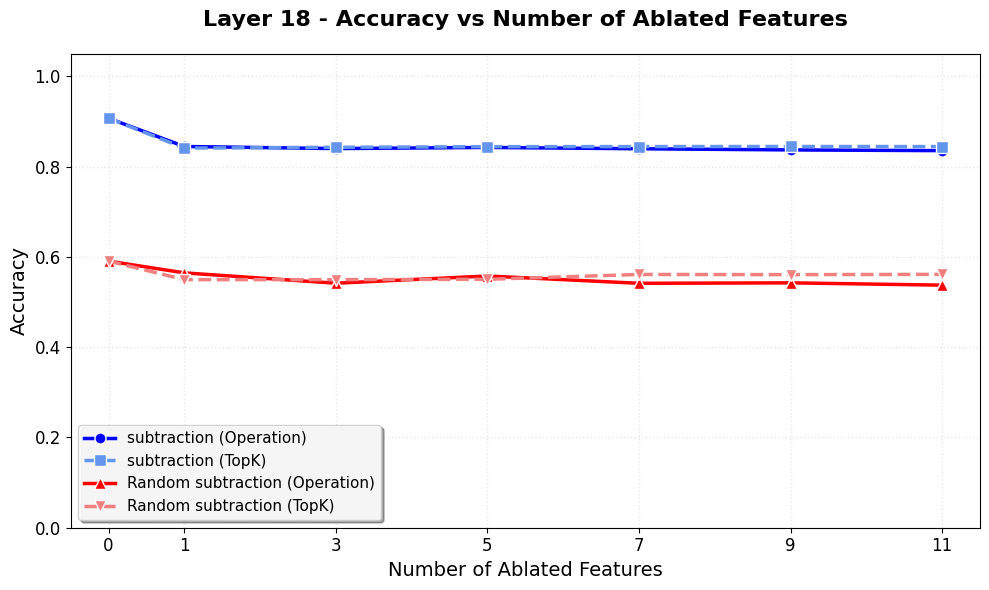

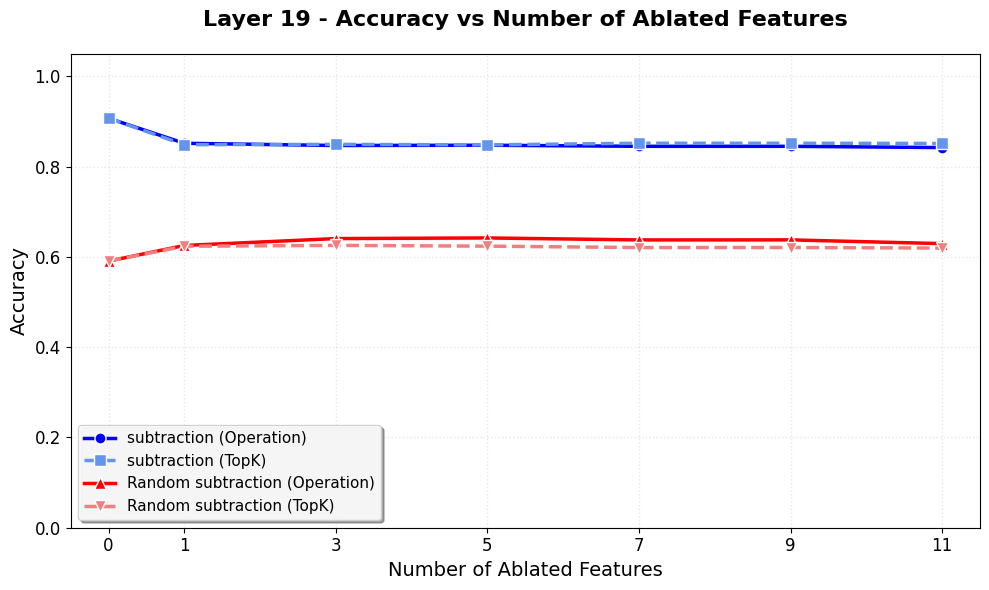

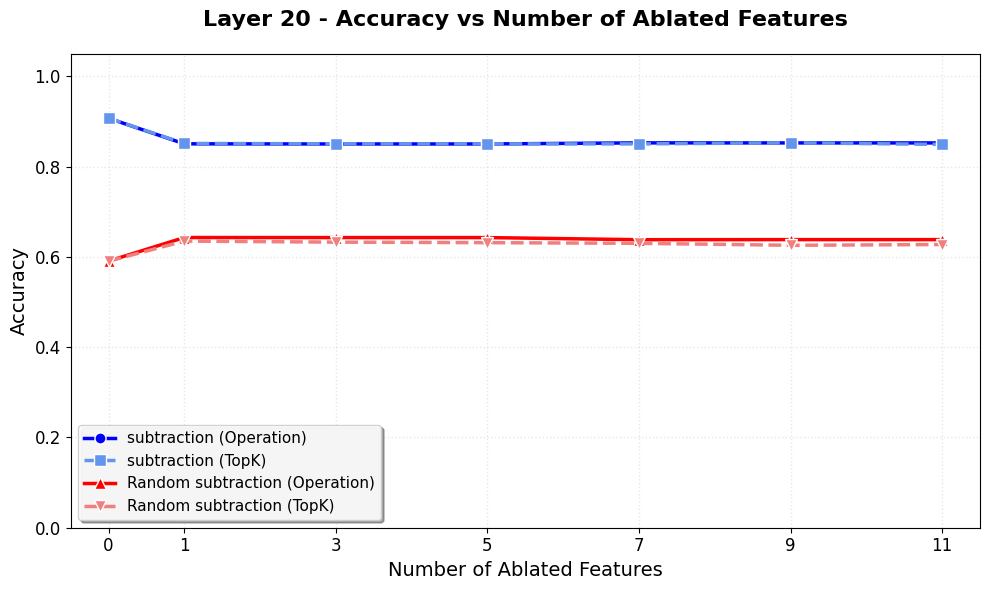

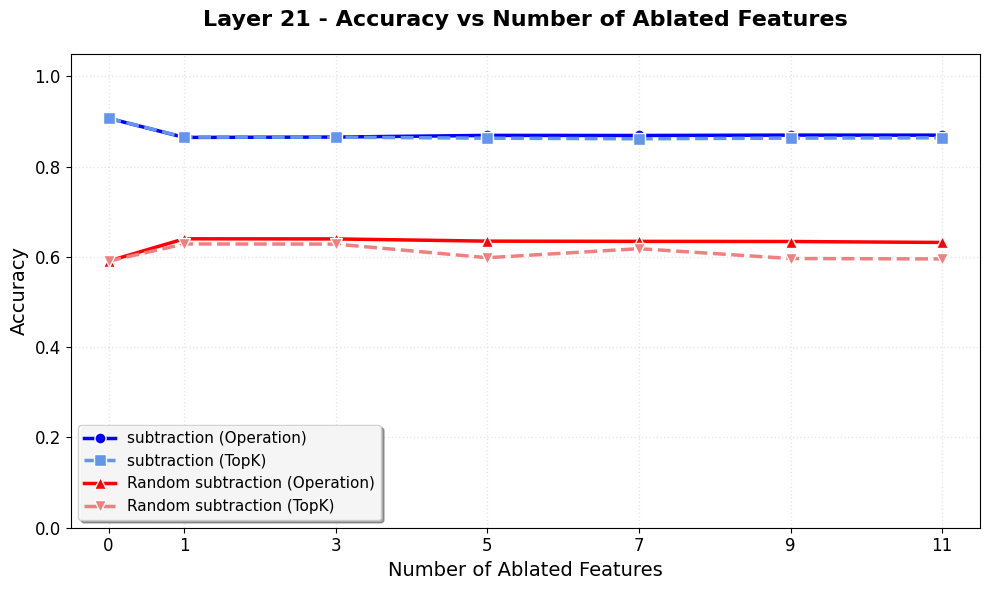

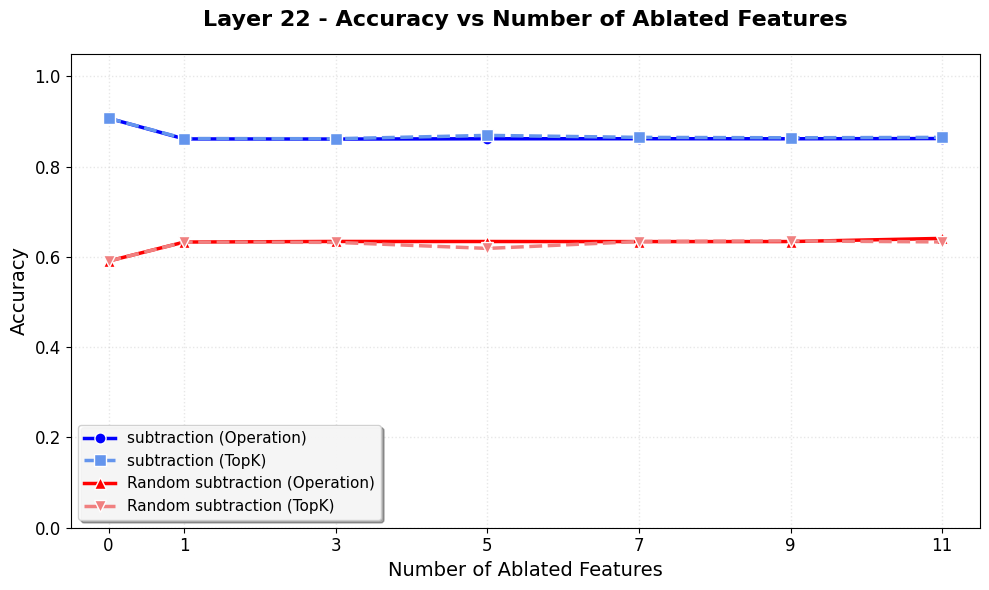

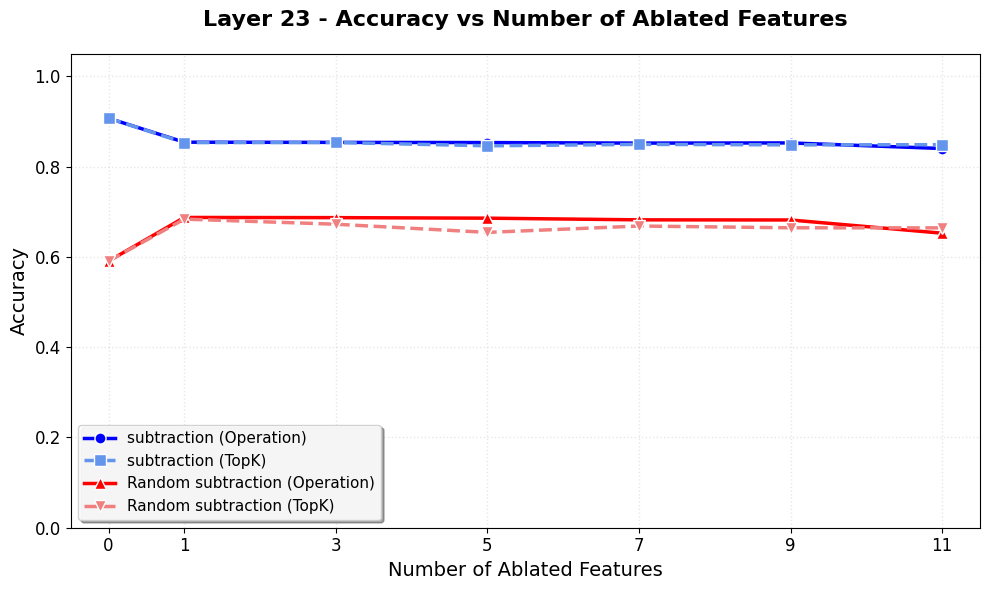

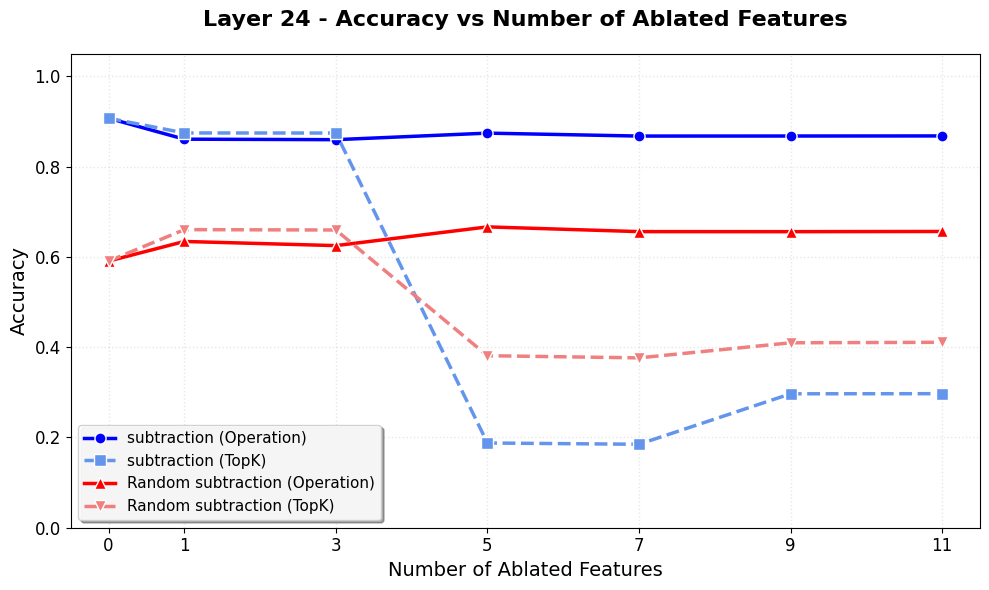

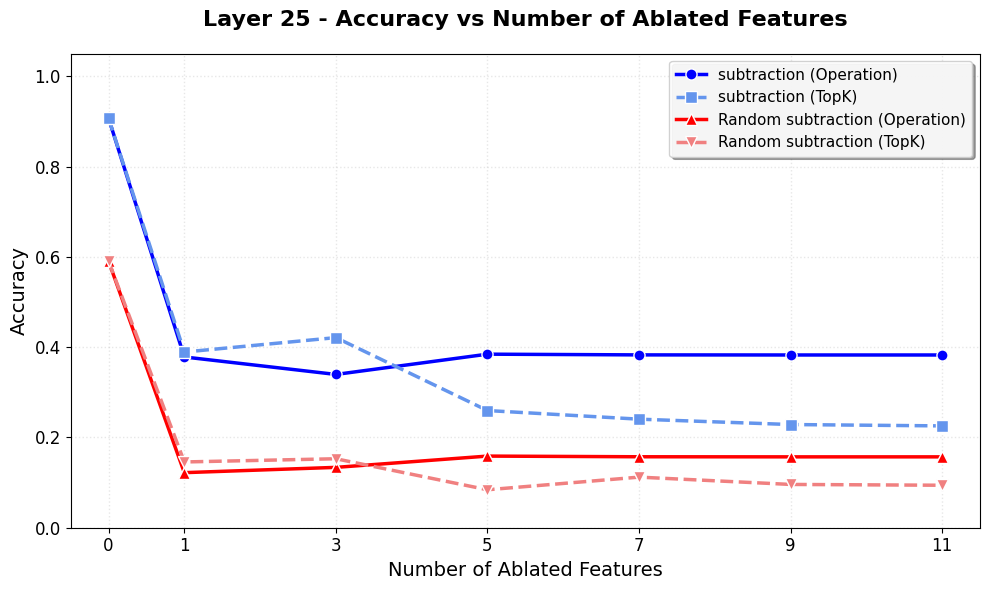

In [9]:
subtraction_config = {
    ('subtraction', 'operation_ablation'): {'color': 'blue', 'linestyle': '-', 'marker': 'o', 'label': 'subtraction (Operation)', 
                                         'name': 'subtraction (Operation)', 'dash': 'solid', 'symbol': 'circle',
                                         'linewidth': 2.5, 'markersize': 8},
    ('subtraction', 'topk_ablation'): {'color': 'cornflowerblue', 'linestyle': '--', 'marker': 's', 'label': 'subtraction (TopK)',
                                    'name': 'subtraction (TopK)', 'dash': 'dash', 'symbol': 'square',
                                    'linewidth': 2.5, 'markersize': 8},
    ('random_subtraction', 'operation_ablation'): {'color': 'red', 'linestyle': '-', 'marker': '^', 'label': 'Random subtraction (Operation)',
                                                'name': 'Random subtraction (Operation)', 'dash': 'solid', 'symbol': 'triangle-up',
                                                'linewidth': 2.5, 'markersize': 8},
    ('random_subtraction', 'topk_ablation'): {'color': 'lightcoral', 'linestyle': '--', 'marker': 'v', 'label': 'Random subtraction (TopK)',
                                           'name': 'Random subtraction (TopK)', 'dash': 'dash', 'symbol': 'triangle-down',
                                           'linewidth': 2.5, 'markersize': 8}
}

# Generate individual plots for each layer
print("Generating individual plots for each layer...")
print("Note: This will create 26 separate plots, one for each layer.")
plot_individual_layer_plots(accuracy_results, subtraction_config)